# Denoising Diffusion Probabilistic Models with miniai

## Complete Beginner's Guide

This notebook builds on our previous DDPM notebooks (15, 17, 18) and introduces several important improvements:

1. **Cosine Noise Schedule**: A better way to add noise during training
2. **HuggingFace Diffusers UNet**: Using a pre-built, well-tested architecture
3. **Skip Sampling**: Techniques to make image generation faster
4. **FID Evaluation**: Measuring the quality of generated images

### Prerequisites
- Basic Python knowledge
- Understanding of PyTorch basics (tensors, nn.Module)
- Familiarity with the DDPM concepts from previous notebooks (optional but helpful)

### Quick DDPM Refresher

DDPM (Denoising Diffusion Probabilistic Models) generate images through a two-phase process:

```
FORWARD PROCESS (Training):
Clean Image --> Add noise step by step --> Pure Noise
    x_0     -->    x_1 --> x_2 --> ... --> x_T

REVERSE PROCESS (Generation):
Pure Noise --> Remove noise step by step --> Clean Image
    x_T    -->    x_{T-1} --> ... --> x_0
```

The neural network learns to predict and remove the noise at each step.

## Google Colab Setup

Run the cells below **once** at the start of each Colab session. They mount Google Drive, set the working directory, install required packages, and clone the `miniai` library from the fast.ai Part 2 course repo.

**GPU note:** Training cells need a GPU. **Runtime &rarr; GPU**.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.chdir('/content/drive/MyDrive/Fast.AI_Colab')
print(os.getcwd())

/content/drive/MyDrive/Fast.AI_Colab


In [ ]:
!pip install -q fastcore fastai diffusers datasets torcheval accelerate
if not os.path.exists('course22p2'):
    !git clone https://github.com/fastai/course22p2.git
import sys
sys.path.insert(0, os.path.join(os.getcwd(), 'course22p2'))
try:
    import miniai
    print(f'miniai loaded from: {miniai.__file__}')
except ImportError:
    print('ERROR: miniai not found.')

miniai loaded from: /content/drive/MyDrive/Fast.AI_Colab/course22p2/miniai/__init__.py


---

*The cells above are Colab-specific setup. The content below is the same as the source notebook (`19_DDPM_v3_explained.ipynb`), unchanged.*

---

## 🧭 The 30-second picture (read this first)

Every piece of this notebook serves one of three ideas:

1. **Forward (destroy).** Take a real image and mix it with Gaussian noise. A *noise schedule* (ᾱ_t) controls how much: t = 0 is the clean image, t = 999 is pure static. One closed-form line jumps to any t — no loop needed.
2. **Train (predict the noise).** Show a UNet the noisy image *and* the number t, and train it — with plain MSE — to output the exact noise that was mixed in. No labels, no adversary, no clean-image target.
3. **Sample (create).** Start from pure static and repeat 1000 times: predict the noise, remove a *small carefully-weighted* amount of it, and add a pinch of fresh noise back. A brand-new image emerges.

If you keep asking "which of the three ideas is this code serving?", nothing in this notebook will feel mysterious.

## 🛠️ Interactive visualizations — one-time setup

The cells marked **🎮 Interactive** below embed standalone HTML/JS visualizations
(stored in the `interactive_viz/` folder, served from the GitHub Pages copy) at **full width**,
auto-fitted to their content height. Run the next cell once, then run any 🎮 cell.

In [ ]:
# ============================================================================
# INTERACTIVE VISUALIZATIONS -- setup (run this cell ONCE).
# Each "🎮 Interactive" cell below loads a standalone HTML file from the
# published copy on GitHub Pages, in an isolated <iframe> (its CSS/JS can't leak
# into the notebook). It is shown FULL WIDTH and auto-fits its content height.
# No local files needed -- the visualizations are read from GitHub.
# ============================================================================
from IPython.display import HTML

def show_viz(path, height="600px"):
    """Embed an interactive visualization full width; it auto-fits its height.
    `path` may be a bare 'interactive_viz/<file>.html' (resolved to the GitHub
    Pages copy) or a full https URL."""
    base = "https://shammun.github.io/shammunul-fastai-notes/notebooks/"
    if not path.startswith("http"):
        path = base + path
    return HTML(
        f'<iframe src="{path}" loading="lazy" allowfullscreen '
        f'style="width:100%;height:{height};border:1px solid #dde5f2;border-radius:12px;'
        f'box-shadow:0 8px 24px rgba(123,92,214,.12);background:#fff;"></iframe>'
        '<script>addEventListener("message",function(e){'
        'if(e.data&&e.data.type==="ce-frame-height"&&e.data.height>50){'
        'var fs=document.querySelectorAll("iframe");for(var i=0;i<fs.length;i++){'
        'if(fs[i].contentWindow===e.source){fs[i].style.height=e.data.height+"px";break;}}}});</script>'
    )

### 🎮 Interactive: DDPM on one screen

Everything this notebook builds, in one playground:

**What to try**
- Click the stage chips — **① forward (destroy) → ② training (predict the noise) → ③ sampling (create)** — each swaps the explanation, the formula, and the highlighted code.
- **Drag the timeline** or **click any thumbnail** to jump the image to that t; watch the √ᾱ (signal) and √(1−ᾱ) (noise) readouts trade places.
- Chip ③ plays the timeline in *reverse* — a preview of the sampling section at the end of the notebook.

In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddpm3_big_picture.html
# at full width, sized to fit the visualization (setup cell near the top required).
# A map of the whole notebook -- come back to it whenever you feel lost.
# ============================================================================
show_viz("interactive_viz/ddpm3_big_picture.html", height="860px")

---
## 🔭 How we got here: notebook 15 → 17 → 19

You've already built DDPM twice. This notebook is the third pass, and it's worth being explicit about what each pass was *for*:

| | **NB 15** — "make it run" | **NB 17** — "make it fast" | **NB 19 (this one)** — "make it good" |
|---|---|---|---|
| Schedule | `linspace(1e-4, 0.02)` hidden in a callback | module-level tensors | **factories** (`linear_sched`/`cos_sched`), compared, then **tuned to betamax=0.01** |
| noisify | in `DDPMCB.before_batch`, on GPU, mid-step | standalone function | standalone, run **in DataLoader workers** via `collate_ddpm` |
| Model | raw `UNet2DModel` + callback unwrapping `.sample` | `UNet` wrapper + `init_ddpm` zero-init | same, **scaled up** to (32,64,128,256) |
| Training | lr 4e-3, 5 epochs, Adam, fp32, bs 128 | lr 1e-2, 8 epochs, `eps=1e-5`, **MixedPrecision**, bs 512 | lr 1e-2, **25 epochs, AdamW**, fp16, bs 512 |
| Sampling | callback method | standalone `sample()` (+ x̂₀ clamp) | standalone **+ `sample_skip` + `sample2`** (3× faster) |
| Evaluation | eyeballing | eyeballing | **FID** via `ImageEval` — quality becomes a number |

Throughout the notebook, **🔍 15 → 17 → 19** boxes appear after each shared building block with the specific comparison; the lab below holds the actual side-by-side code.

### 🎮 Interactive: the Evolution Lab — three notebooks, side by side

Every shared building block of the three DDPM notebooks, with the real code in three columns and the *why* under each:

**What to try**
- Click through the topic chips: **① schedule → ② noisify → ③ model & init → ④ data loading → ⑤ training config → ⑥ sampling → ⑦ evaluation & speed**.
- In each view, highlights mark the story: **orange = the pain point in NB 15**, **teal = NB 17's fix**, **purple = what NB 19 adds**.
- Read the dashed **verdict box** at the bottom of each topic — it names the precise gap notebook 19 closes.
- Come back after finishing the notebook: chip ⑦ is the punchline (measure → change → re-measure).

In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddpm3_evolution_lab.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Orange = NB15 pain point, teal = NB17 fix, purple = NB19 addition.
# ============================================================================
show_viz("interactive_viz/ddpm3_evolution_lab.html", height="880px")

---
## Imports

We'll import all necessary libraries. Don't worry if this seems like a lot - each has a specific purpose that we'll explain as we use them.

In [ ]:
# Select which GPU to use (if you have multiple GPUs)
# '1' means use the second GPU (0-indexed)
# Change to '0' if you only have one GPU
import os
os.environ['CUDA_VISIBLE_DEVICES']='1'

**Why set CUDA_VISIBLE_DEVICES?**

If you have multiple GPUs, this lets you choose which one to use. This must be set BEFORE importing PyTorch, which is why it's in a separate cell at the very top.

| Value | Meaning |
|-------|--------|
| '0' | Use first GPU |
| '1' | Use second GPU |
| '0,1' | Use both GPUs |
| '' | Use CPU only |

In [ ]:
# Standard Python libraries
import pickle,gzip,math,os,time,shutil,torch,random,logging
import fastcore.all as fc  # Fast.ai core utilities
import matplotlib as mpl   # Plotting configuration
import numpy as np         # Numerical operations
import matplotlib.pyplot as plt  # Plotting
from collections.abc import Mapping
from pathlib import Path
from functools import partial  # Create functions with pre-filled arguments

# FastCore utilities
from fastcore.foundation import L  # Enhanced list class

# PyTorch and torchvision
import torchvision.transforms.functional as TF  # Image transformations
import torch.nn.functional as F  # Neural network functions (padding, etc.)
from torch import tensor,nn,optim
from torch.utils.data import DataLoader,default_collate
from torch.nn import init  # Weight initialization
from torch.optim import lr_scheduler  # Learning rate schedulers

# miniai - Fast.ai's minimal deep learning library
from miniai.datasets import *
from miniai.conv import *
from miniai.learner import *
from miniai.activations import *
from miniai.init import *
from miniai.sgd import *
from miniai.resnet import *
from miniai.augment import *
from miniai.accel import *

**Key imports explained:**

| Import | Purpose |
|--------|--------|
| `fastcore.all` | Utility functions from fast.ai |
| `TF` (torchvision.transforms.functional) | Image transformations like `to_tensor` |
| `F` (torch.nn.functional) | Neural network operations like padding |
| `partial` | Pre-fill function arguments (we'll use this for optimizers) |
| `miniai.*` | Custom fast.ai modules for training |

In [ ]:
# Additional imports
from torcheval.metrics import MulticlassAccuracy  # For evaluating classifiers
from datasets import load_dataset,load_dataset_builder  # HuggingFace datasets

# Configure matplotlib to show images in reverse grayscale
# (black background, white foreground - common for Fashion MNIST)
mpl.rcParams['image.cmap'] = 'gray_r'

# Suppress warning messages (keeps output clean)
logging.disable(logging.WARNING)

# Set random seed for reproducibility
# This ensures we get the same random numbers each time we run
set_seed(42)

# Limit CPU workers to 8 (prevents resource exhaustion on big machines)
if fc.defaults.cpus>8: fc.defaults.cpus=8

**Why `set_seed(42)`?**

Neural networks use random numbers extensively (weight initialization, data shuffling, noise generation). Setting a seed means:
- You get the same "random" numbers each run
- Your experiments are reproducible
- 42 is traditionally used (a reference to "Hitchhiker's Guide to the Galaxy")

---
## Loading the Fashion MNIST Dataset

Fashion MNIST is a dataset of 70,000 grayscale images (28x28 pixels) of clothing items. It's a drop-in replacement for the original MNIST handwritten digits, but more challenging.

In [ ]:
# Define column names in the dataset
xl,yl = 'image','label'  # xl = image column, yl = label column

# Name of the dataset to load from HuggingFace
name = "zalando-datasets/fashion_mnist"

# Load the dataset (downloads if not cached)
dsd = load_dataset(name)

# Define a transformation function to preprocess images
@inplace  # Modifies the input dictionary directly (no return needed)
def transformi(b):
    # For each image in the batch:
    # 1. TF.to_tensor(o) - Convert PIL image to tensor (values 0-1)
    # 2. F.pad(..., (2,2,2,2)) - Add 2 pixels of padding on all sides
    #    This changes 28x28 -> 32x32 (better for UNet which uses powers of 2)
    # 3. -0.5 - Center the values around 0 (range becomes -0.5 to 0.5)
    b[xl] = [F.pad(TF.to_tensor(o), (2,2,2,2))-0.5 for o in b[xl]]

# Batch size for training
bs = 512

# Apply the transformation to the dataset
tds = dsd.with_transform(transformi)

# Create DataLoaders (handles batching and shuffling)
dls = DataLoaders.from_dd(tds, bs, num_workers=2)

**Breaking down the transformation:**

```
Original Image    After to_tensor    After padding      After -0.5
  (PIL 28x28)     (Tensor 28x28)     (Tensor 32x32)   (Tensor 32x32)
                   [0.0 - 1.0]        [0.0 - 1.0]     [-0.5 - 0.5]

  +--------+       +--------+        +----------+     +----------+
  |  img   |  -->  |  img   |  -->   |  padding |     |  padding |
  | 28x28  |       | 28x28  |        |   img    |     |   img    |
  +--------+       +--------+        |  padding |     |  padding |
                                     +----------+     +----------+
```

**Why 32x32?** The UNet architecture uses downsampling (halving resolution) multiple times. Starting with 32 (2^5) means we can halve 5 times: 32 -> 16 -> 8 -> 4 -> 2 -> 1, which is cleaner than 28.

**Why center around 0?** Neural networks often work better when input values are centered around 0. Values in range [-0.5, 0.5] are well-suited for many activation functions.

---
## Noise Schedules: Linear vs Cosine

The **noise schedule** determines how much noise to add at each timestep. This is one of the most important design choices in diffusion models.

### Key Variables

| Symbol | Name | Meaning |
|--------|------|--------|
| beta (β) | Variance | How much noise to add at each step |
| alpha (α) | 1 - β | How much of the original signal remains |
| alphabar (ᾱ) | Cumulative α | Product of all alphas up to step t |
| sigma (σ) | √β | Standard deviation of added noise |

In [ ]:
# SimpleNamespace lets us bundle related values together
# Access like: sched.a, sched.abar, sched.sig
from types import SimpleNamespace

**What is SimpleNamespace?**

It's a simple container that lets you access values with dot notation instead of dictionary brackets:

```python
# Dictionary style:
d = {'a': 1, 'b': 2}
print(d['a'])  # 1

# SimpleNamespace style:
ns = SimpleNamespace(a=1, b=2)
print(ns.a)  # 1
```

In [ ]:
def linear_sched(betamin=0.0001, betamax=0.02, n_steps=1000):
    """
    Create a LINEAR noise schedule.

    The original DDPM paper used this schedule. Beta (noise variance)
    increases linearly from betamin to betamax over n_steps.

    Args:
        betamin: Starting variance (very small noise at t=0)
        betamax: Ending variance (large noise at t=T)
        n_steps: Total number of diffusion steps

    Returns:
        SimpleNamespace with:
        - a: alpha values (1 - beta) for each step
        - abar: cumulative product of alphas (alphabar)
        - sig: sigma values (sqrt of beta)
    """
    # Create linearly spaced beta values
    # torch.linspace(start, end, steps) creates evenly spaced values
    beta = torch.linspace(betamin, betamax, n_steps)

    # Calculate alpha = 1 - beta
    # This represents how much of the original signal remains at each step
    a = 1. - beta

    # Calculate alphabar = cumulative product of alphas
    # cumprod computes: [a[0], a[0]*a[1], a[0]*a[1]*a[2], ...]
    # This tells us the TOTAL signal remaining after t steps
    abar = a.cumprod(dim=0)

    # sigma = sqrt(beta)
    sig = beta.sqrt()

    return SimpleNamespace(a=a, abar=abar, sig=sig)

# Understanding `SimpleNamespace` in DDPM Noise Schedules

## The Line in Question

```python
return SimpleNamespace(a=a, abar=abar, sig=sig)
```

This is the final line of the `linear_sched` function, which creates a **linear noise schedule** for the DDPM (Denoising Diffusion Probabilistic Model). But what exactly is it doing, and why was this approach chosen?

---

## What is `SimpleNamespace`?

`SimpleNamespace` is a built-in Python class from the `types` module. It creates a lightweight object where you can store named attributes and access them using **dot notation**.

```python
from types import SimpleNamespace

# Create a namespace with named attributes
ns = SimpleNamespace(a=1, b=2, c=3)

# Access with dot notation
print(ns.a)    # 1
print(ns.b)    # 2
print(ns.c)    # 3

# Compare with dictionary bracket access
d = {'a': 1, 'b': 2, 'c': 3}
print(d['a'])  # 1  ← more verbose, more punctuation
```

Think of it as "a dictionary you can access with dots" — no class definition needed, no boilerplate, just clean attribute access.

---

## What Are We Returning?

The function bundles **three related tensors** that together fully define a noise schedule:

| Attribute | Math Symbol | Shape | Meaning |
|-----------|-------------|-------|---------|
| `a` | α = 1 − β | `(1000,)` | Signal preserved at each individual step |
| `abar` | ᾱ = ∏α | `(1000,)` | **Cumulative** signal remaining after t steps |
| `sig` | σ = √β | `(1000,)` | Noise standard deviation at each step |

These three values are all derived from the same beta schedule and **always travel together** — you never need one without potentially needing the others.

---

## How Is It Used Downstream?

### Unpacking the full schedule (Cell 30)

```python
lin_abar = linear_sched(betamax=0.01)

# Clean dot access — reads almost like math notation
alphabar = lin_abar.abar    # ᾱ values
alpha    = lin_abar.a       # α values
sigma    = lin_abar.sig     # σ values
```

### Grabbing just one value for plotting (Cell 21)

```python
lin_abar = linear_sched().abar       # one-liner: create schedule, grab ᾱ
cos_abar = cos_sched().abar          # same for cosine schedule

plt.plot(lin_abar, label='lin')
plt.plot(cos_abar, label='cos')
```

### Swapping schedules seamlessly

Both `linear_sched()` and `cos_sched()` return the **same interface** — a namespace with `.a`, `.abar`, `.sig`. This means you can swap schedules without changing any downstream code:

```python
# Just change this one line:
sched = linear_sched(betamax=0.01)   # or: sched = cos_sched()

# Everything below works identically
alphabar = sched.abar
alpha    = sched.a
sigma    = sched.sig
```

This is a lightweight form of **polymorphism** — both functions return objects with the same "shape," making them interchangeable.

---

## Why Not Other Approaches? Four Design Alternatives Compared

### Option 1: Return a Tuple

```python
def linear_sched(betamin=0.0001, betamax=0.02, n_steps=1000):
    beta = torch.linspace(betamin, betamax, n_steps)
    a = 1. - beta
    abar = a.cumprod(dim=0)
    sig = beta.sqrt()
    return a, abar, sig  # ← tuple
```

**Usage:**

```python
# Must remember exact order: a, abar, sig
a, abar, sig = linear_sched()

# If you only want abar:
_, abar, _ = linear_sched()   # ← awkward underscore placeholders
```

**Problems:**

- Caller must memorize the position of each value
- If the function is later updated to return a 4th value, every call site breaks
- No self-documentation — what does the 2nd element mean?

### Option 2: Return a Dictionary

```python
def linear_sched(betamin=0.0001, betamax=0.02, n_steps=1000):
    beta = torch.linspace(betamin, betamax, n_steps)
    a = 1. - beta
    abar = a.cumprod(dim=0)
    sig = beta.sqrt()
    return {'a': a, 'abar': abar, 'sig': sig}  # ← dict
```

**Usage:**

```python
sched = linear_sched()

# Bracket + quotes access
alphabar = sched['abar']
alpha    = sched['a']
sigma    = sched['sig']

# Plotting requires brackets
plt.plot(linear_sched()['abar'])  # ← noisy compared to .abar
```

**Problems:**

- `sched['abar']` is more verbose than `sched.abar`
- No autocomplete in most editors (dicts don't advertise their keys)
- Brackets and quotes add visual clutter, especially inline

### Option 3: Define a Dataclass

```python
from dataclasses import dataclass
import torch
from torch import Tensor

@dataclass
class NoiseSchedule:
    """Container for noise schedule parameters."""
    a: Tensor       # alpha values (1 - beta)
    abar: Tensor    # cumulative product of alphas
    sig: Tensor     # sigma values (sqrt of beta)
```

Now the function becomes:

```python
def linear_sched(betamin=0.0001, betamax=0.02, n_steps=1000) -> NoiseSchedule:
    beta = torch.linspace(betamin, betamax, n_steps)
    a = 1. - beta
    abar = a.cumprod(dim=0)
    sig = beta.sqrt()
    return NoiseSchedule(a=a, abar=abar, sig=sig)  # ← dataclass instance
```

**Usage** (identical dot access to SimpleNamespace):

```python
sched = linear_sched(betamax=0.01)

alphabar = sched.abar     # dot access ✓
alpha    = sched.a        # dot access ✓
sigma    = sched.sig      # dot access ✓

# One-liner still works
plt.plot(linear_sched().abar)
```

**What a dataclass gives you for free:**

```python
sched = linear_sched()

# 1. Nice repr for debugging
print(sched)
# NoiseSchedule(a=tensor([0.9999, 0.9999, ...]), abar=tensor([0.9999, ...]), sig=tensor([0.0100, ...]))

# 2. Type hints — editors can autocomplete .a, .abar, .sig
def noisify(x0, schedule: NoiseSchedule):
    ab = schedule.abar  # ← editor knows this exists

# 3. Equality comparison
sched1 = linear_sched()
sched2 = linear_sched()
# sched1 == sched2  (compares field-by-field — though tensors need .equal())

# 4. Immutability (optional)
@dataclass(frozen=True)
class NoiseSchedule:
    a: Tensor
    abar: Tensor
    sig: Tensor

sched.a = something_else  # ← FrozenInstanceError! Prevents accidental mutation
```

**You can also add methods:**

```python
@dataclass
class NoiseSchedule:
    a: Tensor
    abar: Tensor
    sig: Tensor

    def to(self, device):
        """Move all tensors to a device (CPU/GPU)."""
        return NoiseSchedule(
            a=self.a.to(device),
            abar=self.abar.to(device),
            sig=self.sig.to(device)
        )

    def __len__(self):
        """Number of diffusion steps."""
        return len(self.a)

# Usage:
sched = linear_sched().to('cuda')
print(len(sched))  # 1000
```

**When would you prefer a dataclass over SimpleNamespace?**

| Scenario | Prefer |
|----------|--------|
| Quick prototype, notebook, teaching code | `SimpleNamespace` |
| Production codebase, library API | `dataclass` |
| Need type hints / autocomplete | `dataclass` |
| Need immutability guarantees | `dataclass(frozen=True)` |
| Need methods on the object | `dataclass` |
| Used in 2-3 places, throwaway code | `SimpleNamespace` |

**The tradeoff:** A dataclass requires you to define a class upfront (even if it's just 4 lines). For a teaching notebook where the goal is to explain diffusion models — not software engineering — that's unnecessary friction.

### Option 4: SimpleNamespace (What Was Chosen) ✓

```python
return SimpleNamespace(a=a, abar=abar, sig=sig)
```

**Why this wins for a notebook context:**

- **Zero boilerplate** — no class definition needed
- **Dot access** — `sched.abar` reads cleanly
- **Self-documenting** — keyword arguments (`a=a, abar=abar`) make the return values obvious
- **Inline friendly** — `linear_sched().abar` works as a one-liner
- **Same interface as cos_sched** — enables schedule swapping

---

## Summary Comparison Table

| Approach | Dot Access | Boilerplate | Type Hints | Autocomplete | Best For |
|----------|-----------|-------------|------------|-------------|----------|
| **Tuple** | ✗ | None | ✗ | ✗ | Throwaway 2-value returns |
| **Dictionary** | ✗ | None | ✗ | ✗ | Dynamic/unknown keys |
| **Dataclass** | ✓ | ~4 lines | ✓ | ✓ | Production code, libraries |
| **SimpleNamespace** | ✓ | None | ✗ | ✗ | Notebooks, prototypes, teaching |

---

## The Deeper Motivation

This pattern reflects a recurring need in diffusion model code: the noise schedule is a **single conceptual object** (one schedule) that contains **multiple computed quantities** derived from the same source (beta). `SimpleNamespace` is the minimum-ceremony way to express this grouping.

It's a very common pattern in fast.ai / Jeremy Howard-style code, where **pragmatism and readability** are prioritized over formal class hierarchies. The philosophy: use the simplest tool that gets the job done — and for bundling three tensors in a notebook, `SimpleNamespace` is exactly that.

**Linear Schedule Visualization:**

```
Beta (noise added at each step):
    |
  β |                                    ___---
    |                           ___---'''
    |                  ___---'''
    |         ___---'''
    |___---'''
    +------------------------------------------
    0                  t                   1000

Linear: steady increase from betamin to betamax
```

In [ ]:
def abar(t, T):
    """
    Cosine schedule formula for alphabar.

    This is the "Improved DDPM" formula that uses a cosine curve
    instead of linear interpolation.

    Formula: alphabar(t) = cos^2(t/T * pi/2)

    Args:
        t: Current timestep (or tensor of timesteps)
        T: Total number of timesteps

    Returns:
        Alphabar value(s) at timestep(s) t
    """
    # t/T gives a value from 0 to 1
    # Multiply by pi/2 to get angle from 0 to pi/2
    # cos gives values from 1 to 0 over this range
    # Square it to get values from 1 to 0 (smoother curve)
    return (t/T * math.pi/2).cos()**2

**Why cos^2?**

The cosine function naturally provides:
- Value 1 at angle 0 (full signal at start)
- Value 0 at angle π/2 (no signal at end)
- Smooth transition with gentler slopes at both ends

Squaring makes the curve even smoother:

```
cos(x):      cos^2(x):
1|\          1|\  
 | \          | \__
 |  \         |    \__
 |   \        |       \__
0+----\--     0+-----------\--
  0  π/2        0        π/2
```

In [ ]:
def cos_sched(n_steps=1000):
    """
    Create a COSINE noise schedule.

    Introduced in "Improved Denoising Diffusion Probabilistic Models" paper.
    The cosine schedule adds noise more gradually, especially at the
    start and end, which often leads to better image quality.

    Args:
        n_steps: Total number of diffusion steps

    Returns:
        SimpleNamespace with a, abar, and sig values
    """
    # Create timesteps from 0 to n_steps-1
    ts = torch.linspace(0, n_steps-1, n_steps)

    # Calculate alphabar using cosine formula
    ab = abar(ts, n_steps)

    # Calculate alpha from alphabar
    # We know: abar[t] = abar[t-1] * alpha[t]
    # So: alpha[t] = abar[t] / abar[t-1]
    alp = ab / abar(ts-1, n_steps)

    # sigma = sqrt(1 - alpha) = sqrt(beta)
    sig = (1 - alp).sqrt()

    return SimpleNamespace(a=alp, abar=ab, sig=sig)

**How we derive alpha from alphabar:**

```
Given:  ᾱ_t = α_1 × α_2 × ... × α_t     (definition of alphabar)
        ᾱ_{t-1} = α_1 × α_2 × ... × α_{t-1}

Then:   α_t = ᾱ_t / ᾱ_{t-1}

Example with t=3:
        ᾱ_3 = α_1 × α_2 × α_3
        ᾱ_2 = α_1 × α_2
        α_3 = ᾱ_3 / ᾱ_2 = (α_1 × α_2 × α_3) / (α_1 × α_2) = α_3 ✓
```

# Where Is the Cosine in `cos_sched`? A Complete Trace

## The Puzzle

Look at `cos_sched` and try to find the word "cos" or any trigonometry:

```python
def cos_sched(n_steps=1000):
    ts = torch.linspace(0, n_steps-1, n_steps)
    ab = abar(ts, n_steps)                   # ← no cosine visible here
    alp = ab / abar(ts-1, n_steps)           # ← or here
    sig = (1 - alp).sqrt()                   # ← or here
    return SimpleNamespace(a=alp, abar=ab, sig=sig)
```

There is no `.cos()` call anywhere inside this function. So where does the "cosine" in "cosine schedule" actually happen?

---

## Answer: The Cosine Is Hidden Inside the `abar` Helper Function

The cosine lives one level deeper — in a separate helper function called `abar`, defined in Cell 17 of the notebook:

```python
def abar(t, T):
    return (t/T * math.pi/2).cos()**2
    #                         ^^^^
    #                    HERE is the cosine!
```

When `cos_sched` calls `abar(ts, n_steps)`, it's calling this function, which applies **cos²** to the timesteps. The call chain looks like this:

```
cos_sched(n_steps=1000)
    │
    ├── ab = abar(ts, n_steps)
    │         │
    │         └── return (ts/1000 * π/2).cos()**2    ← COSINE IS HERE
    │
    ├── alp = ab / abar(ts-1, n_steps)
    │                │
    │                └── return ((ts-1)/1000 * π/2).cos()**2   ← AND HERE
    │
    └── sig = (1 - alp).sqrt()
```

The function `abar` is called **twice** inside `cos_sched` — both calls use cosine internally:

| Call | Purpose | Computes |
|------|---------|----------|
| `abar(ts, n_steps)` | ᾱ at timestep t | cos²(t/T · π/2) |
| `abar(ts-1, n_steps)` | ᾱ at timestep t−1 | cos²((t−1)/T · π/2) |

---

## The Complete Math: Equation by Equation

### The cosine formula for ᾱ (inside `abar`)

$$
\bar{\alpha}(t) = \cos^2\!\left(\frac{t}{T} \cdot \frac{\pi}{2}\right)
$$

This is the core equation from the "Improved DDPM" paper (Nichol & Dhariwal, 2021). It defines **how much total signal remains** at timestep t using a cosine curve.

**Why cos²?** The cosine function naturally goes from 1 to 0 over the interval [0, π/2], and squaring it makes the transition smoother at both endpoints:

```
              ᾱ(t) = cos²(t/T · π/2)

ᾱ(t)
1.0  ●━━━━╮
          ╰━━╮
              ╰━━╮
                  ╰━━━╮
                      ╰━━━━╮
                            ╰━━━━━━╮
0.0                                ╰━━●
     0    167   333   500   667   833  1000
                     t →

  t=0:    cos²(0)   = 1.0    (100% signal — clean image)
  t=500:  cos²(π/4) = 0.5    (50% signal)
  t=1000: cos²(π/2) = 0.0    (0% signal — pure noise)
```

### Deriving α from ᾱ (the division trick)

By definition, ᾱ is the cumulative product of all individual α values:

$$
\bar{\alpha}_t = \alpha_1 \times \alpha_2 \times \cdots \times \alpha_t
$$

Since we know ᾱ at every timestep, we can recover the individual α at step t by dividing:

$$
\alpha_t = \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}
$$

The cumulative products cancel out:

$$
\frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}} = \frac{\cancel{\alpha_1 \times \alpha_2 \times \cdots \times \alpha_{t-1}} \times \alpha_t}{\cancel{\alpha_1 \times \alpha_2 \times \cdots \times \alpha_{t-1}}} = \alpha_t
$$

Substituting the cosine formula:

$$
\alpha_t = \frac{\cos^2\!\left(\frac{t}{T} \cdot \frac{\pi}{2}\right)}{\cos^2\!\left(\frac{t-1}{T} \cdot \frac{\pi}{2}\right)}
$$

```python
alp = ab / abar(ts-1, n_steps)
#     ᾱ(t)     ᾱ(t-1)
```

### Deriving σ from α

Since α = 1 − β and σ = √β:

$$
\sigma_t = \sqrt{1 - \alpha_t}
$$

```python
sig = (1 - alp).sqrt()
```

### Summary of all equations in `cos_sched`

$$
\boxed{
\begin{aligned}
\text{Timesteps:} \quad & \mathbf{ts} = [0, 1, 2, \ldots, T{-}1] \\[6pt]
\text{Alphabar (via cosine):} \quad & \bar{\alpha}_t = \cos^2\!\left(\frac{t}{T} \cdot \frac{\pi}{2}\right) \\[6pt]
\text{Alpha (by division):} \quad & \alpha_t = \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}} = \frac{\cos^2\left(\frac{t}{T} \cdot \frac{\pi}{2}\right)}{\cos^2\left(\frac{t-1}{T} \cdot \frac{\pi}{2}\right)} \\[6pt]
\text{Sigma:} \quad & \sigma_t = \sqrt{1 - \alpha_t}
\end{aligned}
}
$$

---

## Why Define `abar` as a Separate Function?

This is a deliberate design choice, not an accident. There are two reasons:

### Reason 1: `abar` is called twice with different inputs

```python
ab  = abar(ts, n_steps)       # ᾱ(t)    → for timesteps 0, 1, 2, ..., 999
alp = ab / abar(ts-1, n_steps) # ᾱ(t-1)  → for timesteps -1, 0, 1, ..., 998
```

Without the helper, you'd duplicate the cosine formula:

```python
# Without helper — duplicated logic:
ab  = (ts/n_steps * math.pi/2).cos()**2
alp = ab / ((ts-1)/n_steps * math.pi/2).cos()**2
```

### Reason 2: It enables reuse for comparison plots

The notebook uses `abar` independently in the helper and in `cos_sched`. Separating it makes the code modular.

---

## Contrast: How `linear_sched` Does It (Bottom-Up)

The linear schedule takes the opposite approach — it builds **upward** from β:

```python
def linear_sched(betamin=0.0001, betamax=0.02, n_steps=1000):
    beta = torch.linspace(betamin, betamax, n_steps)  # Define β first
    a = 1. - beta                                      # α = 1 − β
    abar = a.cumprod(dim=0)                            # ᾱ = cumulative product
    sig = beta.sqrt()                                  # σ = √β
    return SimpleNamespace(a=a, abar=abar, sig=sig)
```

Everything is self-contained — no helper function, no external calls. The cosine schedule needs the helper because it works **top-down** (define ᾱ first, derive everything else), and the ᾱ formula must be applied at two different sets of timesteps (t and t−1).

```
LINEAR (bottom-up):              COSINE (top-down):
                                 
  β = linspace(...)              ᾱ(t) = cos²(t/T · π/2)  ← abar() helper
  ↓                                 ↓
  α = 1 − β                     α = ᾱ(t) / ᾱ(t−1)       ← calls abar() twice
  ↓                                 ↓
  ᾱ = cumprod(α)                σ = √(1 − α)
  ↓
  σ = √β
```

---

## How the Schedule Is Used Downstream in the Notebook

Both `linear_sched` and `cos_sched` return the same `SimpleNamespace` with `.a`, `.abar`, `.sig`. This notebook uses `linear_sched(betamax=0.01)` for actual training (after comparing both schedules visually), but the downstream code would work identically with `cos_sched()` — just swap one line.

### Usage 1: Comparison Plots (Cells 22–28)

`cos_sched` is called to visually compare against the linear schedule:

```python
lin_abar = linear_sched().abar    # ᾱ from linear schedule
cos_abar = cos_sched().abar       # ᾱ from cosine schedule ← cos_sched used here

plt.plot(lin_abar, label='lin')
plt.plot(cos_abar, label='cos')
```

Also used to compare the **rate of signal destruction** (how evenly information is removed):

```python
plt.plot(lin_abar[1:]-lin_abar[:-1], label='lin')  # Δᾱ for linear
plt.plot(cos_abar[1:]-cos_abar[:-1], label='cos')  # Δᾱ for cosine
```

The cosine schedule shows a bell-curve shaped rate (slow→fast→slow), while linear shows an ever-increasing rate. This more even distribution of information destruction is why cosine often trains better.

### Usage 2: Setting Up the Schedule for Training (Cell 31)

The chosen schedule's three values are extracted into global variables that power everything else:

```python
lin_abar = linear_sched(betamax=0.01)

alphabar = lin_abar.abar    # ᾱ — used by noisify (forward process)
alpha    = lin_abar.a       # α — used by sample (reverse process)
sigma    = lin_abar.sig     # σ — used by sample (reverse process)
```

> **To switch to cosine, you'd only change this one line:**
> ```python
> sched = cos_sched()  # instead of linear_sched(betamax=0.01)
> alphabar = sched.abar
> alpha    = sched.a
> sigma    = sched.sig
> ```
> Everything downstream would work unchanged.

### Usage 3: Forward Process — `noisify` (Cell 34)

The `noisify` function uses **`alphabar`** to add noise to clean images during training:

```python
def noisify(x0, alphabar):
    t = torch.randint(0, n_steps, (n,), dtype=torch.long)
    epsilon = torch.randn(x0.shape, device=device)
    alphabar_t = alphabar[t].reshape(-1, 1, 1, 1).to(device)

    xt = alphabar_t.sqrt() * x0 + (1 - alphabar_t).sqrt() * epsilon
    return (xt, t.to(device)), epsilon
```

The math being implemented:

$$
x_t = \sqrt{\bar{\alpha}_t} \cdot x_0 + \sqrt{1 - \bar{\alpha}_t} \cdot \epsilon
$$

- `alphabar_t.sqrt() * x0` → the signal component (scaled down)
- `(1 - alphabar_t).sqrt() * epsilon` → the noise component (scaled up)
- At t=0, ᾱ ≈ 1: mostly signal
- At t=999, ᾱ ≈ 0: mostly noise

This is called inside `collate_ddpm` (Cell 50), which means **every training batch** runs through noisify:

```python
def collate_ddpm(b):
    images = default_collate(b)[xl]
    return noisify(images, alphabar)    # ← alphabar used here
```

### Usage 4: Reverse Process — `sample` (Cell 64)

The `sample` function uses **all three** values (`alphabar`, `alpha`, `sigma`) to generate images from noise:

```python
@torch.no_grad()
def sample(model, sz):
    x_t = torch.randn(sz).to(ps)        # Start from pure noise

    for t in reversed(range(n_steps)):   # t = 999, 998, ..., 0
        # ... setup ...

        alphabar_t1 = alphabar[t-1] if t > 0 else torch.tensor(1)
        betabar_t  = 1 - alphabar[t]         # uses alphabar
        betabar_t1 = 1 - alphabar_t1         # uses alphabar

        noise = model((x_t, t_batch))         # predict noise

        # Estimate clean image
        x_0_hat = (x_t - betabar_t.sqrt() * noise) / alphabar[t].sqrt()
        #                                             ^^^^^^^^ alphabar

        # Compute x_{t-1}
        x_t = (x_0_hat * alphabar_t1.sqrt() * (1-alpha[t]) / betabar_t +
        #                                       ^^^^^^^^ alpha
               x_t * alpha[t].sqrt() * betabar_t1 / betabar_t +
        #            ^^^^^^^^ alpha
               sigma[t] * z)
        #      ^^^^^^^^ sigma
```

Here's the math for each piece, showing which schedule value drives it:

**Step 1 — Estimate clean image** (uses `alphabar`):

$$
\hat{x}_0 = \frac{x_t - \sqrt{1 - \bar{\alpha}_t} \cdot \epsilon_\theta}{\sqrt{\bar{\alpha}_t}}
$$

**Step 2 — Compute x_{t−1}** (uses `alphabar`, `alpha`, `sigma`):

$$
x_{t-1} = \frac{\hat{x}_0 \cdot \sqrt{\bar{\alpha}_{t-1}} \cdot (1 - \alpha_t)}{1 - \bar{\alpha}_t} + \frac{x_t \cdot \sqrt{\alpha_t} \cdot (1 - \bar{\alpha}_{t-1})}{1 - \bar{\alpha}_t} + \sigma_t \cdot z
$$

### Usage 5: Skip Sampling Variants (Cells 84 & 94)

Both `sample_skip` and `sample2` use the exact same schedule values in the exact same formulas — they only differ in **which timesteps they call the model at**:

```python
# sample_skip: call model every 3rd step + always for last 50
if t % 3 == 0 or t < 50:
    noise = model((x_t, t_batch))

# sample2: logarithmic spacing (more calls near t=0)
sample_at = {t for t in range(n_steps) if (t+101) % ((t+101)//100) == 0}
if t in sample_at:
    noise = model((x_t, t_batch))
```

The denoising formula itself is identical — `alphabar`, `alpha`, `sigma` are used the same way. The skip strategies just reuse the previous `noise` prediction for timesteps where the model isn't called.

---

## The Complete Data Flow

Here is how the schedule values flow through the entire notebook, from creation to final image generation:

```
┌─────────────────────────────────────────────────────────────┐
│  SCHEDULE CREATION (Cell 31)                                │
│                                                             │
│  linear_sched(betamax=0.01) ──→ SimpleNamespace             │
│  [or: cos_sched()]              ├── .abar  → alphabar       │
│                                 ├── .a     → alpha          │
│                                 └── .sig   → sigma          │
└────────────┬──────────────────────┬───────────────┬─────────┘
             │                      │               │
             ▼                      ▼               ▼
┌─────────────────────┐  ┌──────────────────────────────────┐
│  FORWARD PROCESS    │  │  REVERSE PROCESS (Cells 64/84/94)│
│  noisify (Cell 34)  │  │  sample / sample_skip / sample2  │
│                     │  │                                   │
│  Uses: alphabar     │  │  Uses: alphabar, alpha, sigma    │
│                     │  │                                   │
│  xt = √ᾱ·x₀        │  │  x̂₀ = (xt - √(1-ᾱ)·ε) / √ᾱ    │
│     + √(1-ᾱ)·ε     │  │  xt₋₁ = f(x̂₀, ᾱ, α) + σ·z     │
└──────────┬──────────┘  └──────────────┬───────────────────┘
           │                            │
           ▼                            ▼
┌────────────────────┐     ┌────────────────────────┐
│ TRAINING           │     │ GENERATION              │
│ collate_ddpm       │     │                         │
│ → DataLoader       │     │ samples = sample(model, │
│ → learn.fit(25)    │     │    (512, 1, 32, 32))    │
│                    │     │                         │
│ Model learns to    │     │ Start from noise,       │
│ predict ε from xt  │     │ iteratively denoise     │
└────────────────────┘     └────────────────────────┘
```

---

## Summary

The "cosine" in `cos_sched` is **not missing** — it's **delegated** to the `abar` helper function. This is a clean separation of concerns:

- **`abar(t, T)`** — owns the math: `cos²(t/T · π/2)`
- **`cos_sched()`** — owns the orchestration: calls `abar` twice (for t and t−1), divides to get α, derives σ

The three returned values (`alphabar`, `alpha`, `sigma`) then flow into every major operation in the diffusion pipeline: `noisify` uses `alphabar` to add noise during training, and `sample` uses all three to remove noise during generation. Switching from linear to cosine schedule requires changing exactly one line — the rest of the notebook works unchanged.

# Is Alphabar the Amount of Noise?

## Short Answer: No — It's the Opposite

**Alphabar (ᾱ) is the amount of *signal* remaining**, not the amount of noise.

---

## Where This Becomes Clear: The Forward Diffusion Formula

The `noisify` function (Cell 34 of the notebook) implements:

$$
x_t = \underbrace{\sqrt{\bar{\alpha}_t} \cdot x_0}_{\text{signal component}} + \underbrace{\sqrt{1 - \bar{\alpha}_t} \cdot \epsilon}_{\text{noise component}}
$$

```python
xt = alphabar_t.sqrt() * x0 + (1 - alphabar_t).sqrt() * epsilon
#    ^^^^^^^^^^^^^^^^^^^         ^^^^^^^^^^^^^^^^^^^^^
#    signal weight               noise weight
```

The two coefficients control the mix between clean image and noise:

| Timestep | ᾱ value | √ᾱ (signal weight) | √(1−ᾱ) (noise weight) | What you see |
|----------|---------|--------------------|-----------------------|-------------|
| t = 0 | ≈ 1.0 | ≈ 1.0 | ≈ 0.0 | Clean image |
| t = 500 | ≈ 0.5 | ≈ 0.71 | ≈ 0.71 | Equal mix |
| t = 999 | ≈ 0.0 | ≈ 0.0 | ≈ 1.0 | Pure noise |

**ᾱ ≈ 1 means almost no noise** (clean image). **ᾱ ≈ 0 means almost all noise** (pure static).

---

## Visual Intuition

The comparison plot in Cell 22 of the notebook plots ᾱ over time. Its y-axis is labeled "Alphabar (signal remaining)" and the curves go **from 1 down to 0**:

```
ᾱ (signal remaining)
1.0  ●━━━━╮
           ╰━━╮
               ╰━━╮           Signal is being DESTROYED
                   ╰━━━╮      over time. ᾱ tracks how
                       ╰━━━╮  much is LEFT.
                            ╰━━━━╮
0.0                              ╰━━●
     0    200   400   600   800   1000
                  t →
```

This shows signal being *destroyed* — not noise being accumulated.

---

## So What *Is* the Amount of Noise?

The complement: **`1 − ᾱ`**.

The `sample` function (Cell 64) gives this quantity its own name — `betabar_t`:

```python
betabar_t = 1 - alphabar[t]      # ← THIS is the noise proportion
```

The two quantities are complementary and always sum to 1:

```
t=0:    ᾱ = 1.0    1−ᾱ = 0.0    (all signal, no noise)
t=500:  ᾱ = 0.5    1−ᾱ = 0.5    (half and half)
t=999:  ᾱ = 0.0    1−ᾱ = 1.0    (no signal, all noise)

         ᾱ + (1−ᾱ) = 1  always
```

---

## The Naming Convention

The notation is inherited from the original DDPM paper (Ho et al., 2020) and follows a consistent pattern throughout the notebook:

| Symbol | Name | What it measures | Range | Code variable |
|--------|------|-----------------|-------|---------------|
| β (beta) | Variance | Noise added at **one** step | small → larger | `beta` |
| α = 1−β | Alpha | Signal kept at **one** step | ~1 → ~0.99 | `alpha` |
| ᾱ = ∏α | Alphabar | **Total** signal remaining after t steps | 1 → 0 | `alphabar` |
| 1−ᾱ | Betabar | **Total** noise accumulated after t steps | 0 → 1 | `betabar_t` |
| σ = √β | Sigma | Noise std dev at one step | small | `sigma` |

The key insight: **alpha-family quantities (α, ᾱ) always measure signal. Beta-family quantities (β, 1−ᾱ) always measure noise.** The "bar" (ᾱ, 1−ᾱ) means cumulative across all steps; without the bar (α, β) means at a single step.

---

## Where Each Appears in the Notebook

### `alphabar` (ᾱ) — signal remaining — used in both forward and reverse

**Forward process** (`noisify`, Cell 34) — scales the clean image down and the noise up:

```python
xt = alphabar_t.sqrt() * x0 + (1 - alphabar_t).sqrt() * epsilon
```

**Reverse process** (`sample`, Cell 64) — estimates clean image from noisy one:

```python
x_0_hat = (x_t - betabar_t.sqrt() * noise) / alphabar[t].sqrt()
#                                              ^^^^^^^^
#                     divide by √ᾱ to "undo" the signal scaling
```

### `1 - alphabar` (1−ᾱ) — noise accumulated — used in reverse process

Called `betabar_t` in the sampling code:

```python
betabar_t  = 1 - alphabar[t]        # noise proportion at step t
betabar_t1 = 1 - alphabar_t1        # noise proportion at step t-1
```

These appear in the denominator of the DDPM update formula, governing how much to weight the current noisy image vs. the clean image estimate:

```python
x_t = (x_0_hat * alphabar_t1.sqrt() * (1-alpha[t]) / betabar_t +
       x_t * alpha[t].sqrt() * betabar_t1 / betabar_t +
       sigma[t] * z)
```

---

## Summary

$$
\boxed{
\bar{\alpha}_t = \text{signal remaining} \qquad\qquad 1 - \bar{\alpha}_t = \text{noise accumulated}
}
$$

They are two sides of the same coin. The notebook (and the DDPM literature) tracks ᾱ because it's what you define the schedule in terms of — the cosine schedule directly specifies ᾱ(t) = cos²(t/T · π/2), and the linear schedule computes ᾱ as the cumulative product of (1 − β). The noise proportion is simply `1 − ᾱ` whenever you need it.

---
## Comparing Linear vs Cosine Schedules

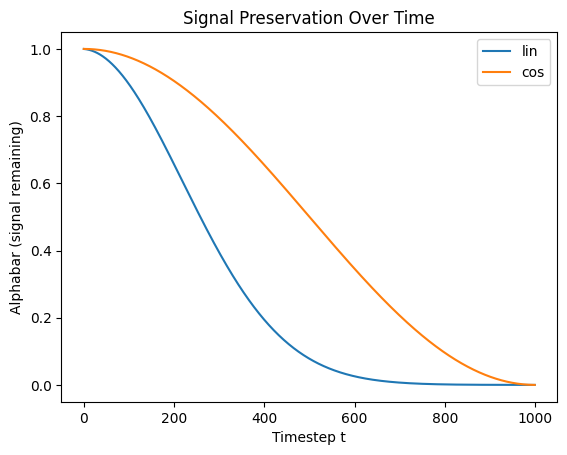

In [ ]:
# Get alphabar values for both schedules
lin_abar = linear_sched().abar  # Default: betamax=0.02
cos_abar = cos_sched().abar

# Plot them together
plt.plot(lin_abar, label='lin')  # Linear schedule
plt.plot(cos_abar, label='cos')  # Cosine schedule
plt.xlabel('Timestep t')
plt.ylabel('Alphabar (signal remaining)')
plt.title('Signal Preservation Over Time')
plt.legend();

**What this plot shows:**

- Y-axis (Alphabar) = how much original signal remains
- At t=0: alphabar ≈ 1 (almost all signal)
- At t=1000: alphabar ≈ 0 (almost no signal)

The **cosine schedule** (orange) preserves more signal for longer, then drops more steeply at the end. This is often better because:
1. More signal in early steps = easier learning
2. The model spends less time on nearly-pure noise

### 🎮 Interactive: the Noise Schedule Lab

The static plots above, but alive — and connected to what an image *actually looks like* at every ᾱ:

**What to try**
- Build the idea up with the chips: **① β (noise added per step) → ② α = 1−β (signal kept) → ③ ᾱ = cumprod (total signal left) → ④ Δᾱ (destruction rate)** — each highlights the matching line in `linear_sched` / `cos_sched`.
- **Click (or drag) anywhere on the plot** to pick a timestep: the right panel shows the *same image with the same ε* under both schedules side by side.
- Drag the **linear betamax** slider (this is the `betamax=0.01` experiment below, live) and watch the orange curve — can you make linear behave more like cosine?
- On chip ④, see the key flaw: the linear schedule wastes its final ~300 steps on images that are already pure noise, while cosine spreads the destruction evenly.

In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddpm3_schedule_lab.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Chip ④ (Δᾱ) shows WHY the cosine schedule was proposed.
# ============================================================================
show_viz("interactive_viz/ddpm3_schedule_lab.html", height="800px")

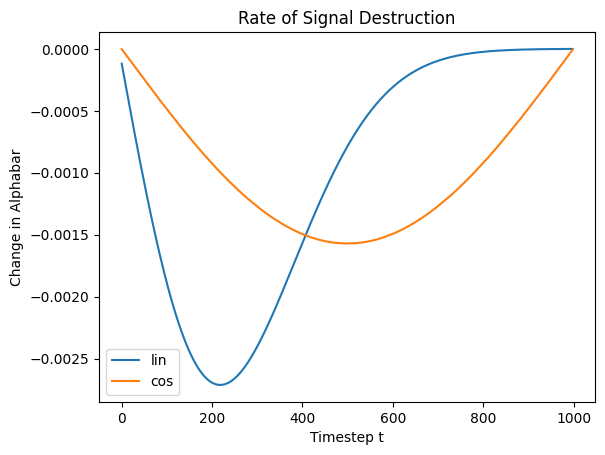

In [ ]:
# Plot the CHANGE in alphabar at each step
# This shows how quickly signal is being destroyed
plt.plot(lin_abar[1:]-lin_abar[:-1], label='lin')  # Difference between consecutive values
plt.plot(cos_abar[1:]-cos_abar[:-1], label='cos')
plt.xlabel('Timestep t')
plt.ylabel('Change in Alphabar')
plt.title('Rate of Signal Destruction')
plt.legend();

**Understanding the rate of change:**

This plot shows `Δ(alphabar) = alphabar[t] - alphabar[t-1]`

- **Linear**: The rate of signal destruction increases over time (accelerating destruction)
- **Cosine**: More uniform rate, with slower destruction at start AND end

The cosine schedule's more even distribution of information destruction often leads to better training.

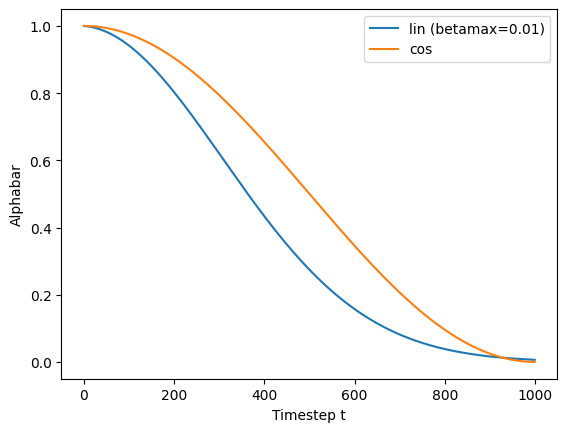

In [ ]:
# Let's try a modified linear schedule with smaller betamax
lin_abar = linear_sched(betamax=0.01).abar  # Half the maximum noise
plt.plot(lin_abar, label='lin (betamax=0.01)')
plt.plot(cos_abar, label='cos')
plt.xlabel('Timestep t')
plt.ylabel('Alphabar')
plt.legend();

With `betamax=0.01` (half the default), the linear schedule preserves more signal and looks more similar to the cosine schedule.

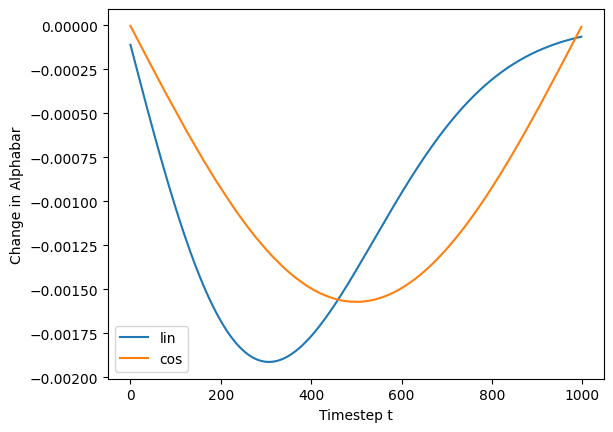

In [ ]:
# Compare the rates of change with the new betamax
plt.plot(lin_abar[1:]-lin_abar[:-1], label='lin')
plt.plot(cos_abar[1:]-cos_abar[:-1], label='cos')
plt.xlabel('Timestep t')
plt.ylabel('Change in Alphabar')
plt.legend();

Even with adjusted `betamax`, the linear schedule still has that increasing rate of destruction, while cosine maintains its characteristic bell-curve shape (slow at ends, faster in middle).

---
## Setting Up the Schedule for Training

We'll use the modified linear schedule with `betamax=0.01` for this notebook.

In [ ]:
# Number of diffusion steps (standard value)
n_steps = 1000

# Create the linear schedule with reduced maximum noise
lin_abar = linear_sched(betamax=0.01)

# Extract the key values we'll need throughout
alphabar = lin_abar.abar  # Cumulative signal preservation
alpha = lin_abar.a        # Signal preservation per step
sigma = lin_abar.sig      # Noise standard deviation per step

**Summary of our schedule values:**

| Variable | Shape | Range | Purpose |
|----------|-------|-------|--------|
| `alphabar` | (1000,) | ~1 → ~0 | Total signal after t steps |
| `alpha` | (1000,) | ~0.9999 → ~0.99 | Signal preserved at step t |
| `sigma` | (1000,) | ~0.01 → ~0.1 | Noise std dev at step t |

### 🔍 15 → 17 → 19: the schedule stops being furniture

- **NB 15:** β, α, ᾱ, σ are computed **inside `DDPMCB.__init__`** with `betamax=0.02` hard-coded at the call site. The schedule is furniture — present, unquestioned.
- **NB 17:** promotes them to module-level tensors. Now they're *visible* (plottable, reusable by `sample`), but there is still exactly one schedule.
- **NB 19:** wraps them in **factories** (`linear_sched`, `cos_sched`) returning a `SimpleNamespace` — schedules become swappable objects. And that immediately paid off: the Δᾱ comparison above exposed that linear-`0.02` burns nearly all signal long before t=999 (wasted steps), which is why this notebook trains with **`betamax=0.01`** — a genuine improvement over both earlier notebooks at zero runtime cost.

So when you see `sc = linear_sched(betamax=0.01)` below, read it as: *the first time in this course the noise schedule was treated as a hyperparameter and tuned with evidence.*

---
## The Noisify Function

This function implements the **forward diffusion process** - adding noise to clean images.

In [ ]:
def noisify(x0, alphabar):
    """
    Add noise to clean images according to the forward diffusion process.

    The key formula is:
        x_t = sqrt(alphabar_t) * x_0 + sqrt(1 - alphabar_t) * epsilon

    This directly jumps from x_0 to any x_t without computing intermediate steps!

    Args:
        x0: Clean images, shape (batch, channels, height, width)
        alphabar: Tensor of cumulative alpha values for all timesteps

    Returns:
        Tuple of ((noisy_images, timesteps), noise)
        - noisy_images: The images with noise added
        - timesteps: Which timestep each image was noised to
        - noise: The actual noise that was added (this is what we train the model to predict)
    """
    device = x0.device  # Keep everything on the same device (CPU/GPU)
    n = len(x0)  # Batch size

    # Sample random timesteps for each image in the batch
    # Each image gets a different random timestep
    t = torch.randint(0, n_steps, (n,), dtype=torch.long)

    # Generate random Gaussian noise (same shape as input images)
    # This is the epsilon (ε) in our formula
    epsilon = torch.randn(x0.shape, device=device)

    # Get alphabar values for the sampled timesteps
    # Reshape to (batch, 1, 1, 1) for broadcasting with image dimensions
    alphabar_t = alphabar[t].reshape(-1, 1, 1, 1).to(device)

    # Apply the forward diffusion formula:
    # x_t = sqrt(alphabar_t) * x_0 + sqrt(1 - alphabar_t) * epsilon
    #       |__________________|   |_________________________|
    #        scaled clean image     scaled noise
    xt = alphabar_t.sqrt() * x0 + (1 - alphabar_t).sqrt() * epsilon

    # Return noisy images with their timesteps, and the noise that was added
    return (xt, t.to(device)), epsilon

**Understanding the forward diffusion formula:**

```
x_t = sqrt(ᾱ_t) * x_0  +  sqrt(1-ᾱ_t) * ε
      ↓                   ↓
      Signal component    Noise component

At t=0:   ᾱ ≈ 1   → x_t ≈ 1*x_0 + 0*ε = x_0        (pure signal)
At t=500: ᾱ ≈ 0.5 → x_t ≈ 0.7*x_0 + 0.7*ε          (equal mix)
At t=999: ᾱ ≈ 0   → x_t ≈ 0*x_0 + 1*ε = ε          (pure noise)
```

The coefficients `sqrt(ᾱ)` and `sqrt(1-ᾱ)` are chosen so that:
- The variance stays normalized (sqrt(ᾱ)² + sqrt(1-ᾱ)² = ᾱ + (1-ᾱ) = 1)
- The image smoothly transitions from signal to noise

### 🔍 15 → 17 → 19: same formula, three homes

The math `x_t = √ᾱ_t·x₀ + √(1−ᾱ_t)·ε` is byte-for-byte the same idea in all three notebooks. What evolves is *where it runs*:

- **NB 15:** inside `DDPMCB.before_batch` — rewrites `learn.batch` on the **GPU, during the training step**. Simple, but untestable in isolation and the GPU idles while it happens.
- **NB 17:** extracted into the standalone `noisify(x0, ᾱ)` you see above — now you can call it on 25 images and plot the "titled noisy grid", unit-test it, and reuse it at sampling time.
- **NB 19:** keeps 17's function *and* its best placement — inside `collate_ddpm` (next section), so CPU workers noisify in parallel with GPU training.

Beginner takeaway: this is the fast.ai refactoring pattern in miniature — **first make it work (callback), then make it a function (testable), then move it off the critical path (collate)**.

### 🎮 Interactive: the `noisify()` machine — one batch, four moves

The formula you just read, acted out on a live mini-batch of six images:

**What to try**
- Walk the chips: **① a random t for every image → ② one ε field per image → ③ shrink the signal by √ᾱ_t → ④ blend in noise by √(1−ᾱ_t)** — each stage highlights the exact line inside `noisify()`.
- **Click any image column** to inspect its numbers: its personal t, its ᾱ_t, and its signal/noise coefficients (the orange/purple bar under each image).
- Press **🎲 New batch** to redraw the random timesteps — notice how one batch simultaneously trains the model on nearly-clean *and* nearly-destroyed images. That per-image randomness is why a single network learns all 1000 noise levels.

In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddpm3_noisify_machine.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Watch how (√ᾱ)² + (√(1−ᾱ))² = 1 keeps total variance constant.
# ============================================================================
show_viz("interactive_viz/ddpm3_noisify_machine.html", height="820px")

---
## Visualizing the Noisification Process

In [ ]:
# Get a batch of data to visualize
dt = dls.train  # Training dataloader
xb, yb = next(iter(dt))  # Get one batch (xb=images, yb=labels)

In [ ]:
# Apply noisify to the first 25 images
(xt, t), epsilon = noisify(xb[:25], alphabar)

# Show the randomly sampled timesteps
t

tensor([ 26, 335, 620, 924, 950, 113, 378,  14, 210, 954, 231, 572, 315, 295,
        567, 706, 749, 876,  73, 111, 899, 213, 541, 769, 287])

Each number is a timestep. Lower numbers = less noise, higher numbers = more noise.

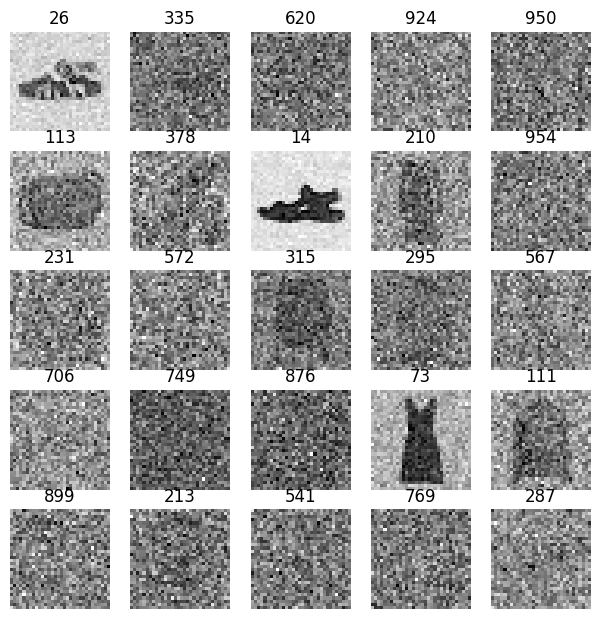

In [ ]:
# Create title labels showing the timestep for each image
# fc.map_ex applies the format string '{}' to each element of t[:25]
titles = fc.map_ex(t[:25], '{}')

# Display the noisy images with their timesteps as titles
show_images(xt[:25], imsize=1.5, titles=titles)

**What you should see:**

- Images with low timesteps (like 14, 26) look almost clean
- Images with medium timesteps (like 400-600) are partially visible
- Images with high timesteps (like 900+) are mostly noise

The model's job is to predict the noise in each image, given the image and its timestep.

### 🎮 Interactive (3D): the *whole dataset* diffusing — not just one image

So far we noised individual images. Zoom out: imagine every image squashed to a point (here 3-D instead of ~1000-D so we can see it). The dataset forms a structured shape — and diffusion **melts that shape into a featureless Gaussian ball**:

**What to try**
- **Drag to rotate, scroll to zoom** (three.js). Press ▶ and watch the two spirals (two "classes") dissolve as t → 999.
- Click chip **④ reverse** to watch the ball collapse back onto the data shape — this is what sampling does, and it's why we can start generation from `torch.randn`: the endpoint of the forward process is a distribution we can sample exactly.
- Pause around t ≈ 300 and rotate: the class structure is still faintly visible — this is the regime where the model learns the most useful signal.

In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddpm3_dataset_diffusion_3d.html
# at full width, sized to fit the visualization (setup cell near the top required).
# NOTE: needs internet access (loads three.js from cdnjs).
# ============================================================================
show_viz("interactive_viz/ddpm3_dataset_diffusion_3d.html", height="760px")

---
## Training

### The UNet Architecture

We'll use the `UNet2DModel` from HuggingFace's `diffusers` library. This is a well-tested implementation used in many state-of-the-art diffusion models.

In [ ]:
# Import the UNet from HuggingFace diffusers library
from diffusers import UNet2DModel

**What is a UNet?**

A UNet is a neural network architecture shaped like the letter "U":

```
Input                              Output
  32x32 ─────────────────────────> 32x32
    ↓                                ↑
   16x16 ───────────────────────> 16x16
      ↓                              ↑
     8x8 ─────────────────────────> 8x8
        ↓                            ↑
       4x4 ────────────────────── > 4x4
          ↓       bottleneck       ↑
          ↓ ─────── 2x2 ────────> ↑
```

- **Left side (encoder)**: Reduces spatial resolution, increases channels
- **Bottom (bottleneck)**: Processes the most compressed representation
- **Right side (decoder)**: Increases spatial resolution, decreases channels
- **Skip connections (─────>)**: Pass information from encoder to decoder at each level

### 🎮 Interactive (3D): ride the U

The ASCII "U" above, rebuilt as an actual U you can fly around — this is the exact architecture instantiated below (`block_out_channels=(32, 64, 128, 256)` on 32×32 inputs). The **orange box is the batch itself**: big face = big spatial grid, thick body = many channels.

**What to try**
- Press **▶ Play all** (or step with **⏮ / ⏭**) and watch the batch ride the U: its shape label morphs at every block — `[bs,1,32,32] → … → [bs,256,4,4] → … → [bs,1,32,32]` — while the input image visibly *fades off its face* as spatial identity is spent.
- Watch the **teal skip packets**: at `down₀–down₂` a copy pops onto a dashed highway and parks; when the batch reaches the matching `up` block the packet **dives in and the box momentarily swells — that's channel concatenation**, the reason UNet noise predictions are pixel-precise.
- The code panel shows the **full model** at all times — the exact notebook code plus one line per block it builds — and the **line for the block the batch currently occupies stays lit** as the animation runs (or when you step, click a block, or click a pill). Chips softly highlight their whole code region and ②–④ *replay* their leg of the journey.
- On chip ⑤, drag the **t slider** and watch the sin/cos barcode by the purple node change — that pattern is broadcast into *every* block (the purple pulses you saw riding the risers), which is how one network denoises at all 1000 noise levels.
- **Click any block** (or any pill underneath) to inspect its tensor shape and its job. Drag to rotate, scroll to zoom.


In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddpm3_unet_3d.html
# at full width, sized to fit the visualization (setup cell near the top required).
# The orange box IS the batch: watch it reshape, and watch skip packets get
# saved on the way down and concatenated (the box swells!) on the way up.
# ============================================================================
show_viz("interactive_viz/ddpm3_unet_3d.html", height="780px")

In [ ]:
class UNet(UNet2DModel):
    """
    A thin wrapper around HuggingFace's UNet2DModel.

    The original UNet2DModel returns a NamedTuple with a .sample attribute.
    Our training loop expects just the tensor, so we extract .sample.

    Also, the original expects (x, t) as separate arguments, but our
    training setup passes them as a tuple, so we unpack them.
    """
    def forward(self, x):
        # x is a tuple of (noisy_image, timesteps)
        # *x unpacks it to pass as separate arguments
        # super().forward(*x) calls the parent class method
        # .sample extracts just the output tensor
        return super().forward(*x).sample

**Why wrap UNet2DModel?**

The HuggingFace UNet has a specific interface that doesn't quite match our training setup:

```python
# HuggingFace expects:
output = model(noisy_images, timesteps)  # Two separate arguments
result = output.sample  # Extract from named tuple

# Our training provides:
output = model((noisy_images, timesteps))  # Single tuple argument
result = output  # Just the tensor

# Our wrapper converts between these interfaces
```

In [ ]:
def init_ddpm(model):
    """
    Initialize the UNet weights for DDPM training.

    This initialization helps training stability:
    1. Zero out the last conv in each residual block (residual connection starts at identity)
    2. Use orthogonal initialization for downsampling layers
    3. Zero out the final output convolution

    Args:
        model: The UNet2DModel to initialize
    """
    # Initialize down blocks (encoder)
    for o in model.down_blocks:
        for p in o.resnets:
            # Zero the last conv in each ResNet block
            # This makes the block initially act as identity
            p.conv2.weight.data.zero_()
        # Orthogonal init for downsampling convolutions
        for p in fc.L(o.downsamplers):
            init.orthogonal_(p.conv.weight)

    # Initialize up blocks (decoder)
    for o in model.up_blocks:
        for p in o.resnets:
            # Same: zero the last conv in each ResNet block
            p.conv2.weight.data.zero_()

    # Zero the final output convolution
    # Model initially predicts zero noise
    model.conv_out.weight.data.zero_()

**Why this initialization?**

1. **Zeroing conv2 in ResNets**: A ResNet block computes `output = input + f(input)`. If we zero the weights of `f`, then initially `f(input) = 0` and `output = input`. This is called "identity initialization" and helps gradients flow better at the start of training.

2. **Orthogonal initialization**: For downsampling layers, orthogonal matrices preserve the magnitude of vectors, preventing the signal from exploding or vanishing.

3. **Zeroing conv_out**: The model initially predicts zero noise, which is a reasonable starting point.

### 🔍 15 → 17 → 19: the model grows a wrapper, an init, and then muscles

| | NB 15 | NB 17 | NB 19 (here) |
|---|---|---|---|
| Model call | raw `UNet2DModel`; a callback's `after_predict` unpacks `learn.preds.sample` | **`UNet` wrapper**: `forward(self, x): return super().forward(*x).sample` | same wrapper |
| Init | default HF init | **`init_ddpm`**: zero the 2nd conv of every ResBlock, orthogonal downsamplers, zero `conv_out` | same init |
| Width | (32, 64, 128, 128) | (16, 32, 64, 128) | **(32, 64, 128, 256)** |

- **The wrapper (17)** turns diffusers' object-returning model into a plain *tensors-in / tensor-out* module — so the generic `TrainLearner` works with **no diffusion-specific callback at all**. Notebook 15 needed `DDPMCB` partly just to unwrap `.sample` every step.
- **`init_ddpm` (17)** makes each residual block start as the identity (`x + f(x)` with `f ≈ 0`) and the whole network output ≈ 0 (matching ε's mean). Early training is then well-behaved enough for the aggressive `lr=1e-2` below.
- **19's change is capacity:** doubling the deepest widths to 256 channels. It's the one knob 15/17 couldn't responsibly turn — without FID (later in this notebook), "bigger" is just "slower with vibes".

---
### Custom Collate Function

A collate function determines how individual data samples are combined into batches.

In [ ]:
def collate_ddpm(b):
    """
    Custom collate function for DDPM training.

    Instead of returning (images, labels), we return:
    - Input: (noisy_images, timesteps)
    - Target: the noise that was added

    Args:
        b: A list of samples from the dataset

    Returns:
        ((noisy_images, timesteps), noise)
    """
    # default_collate stacks samples into a batch
    # We only need the images (xl), not the labels
    images = default_collate(b)[xl]

    # Add noise to the images
    return noisify(images, alphabar)


def dl_ddpm(ds, nw=4):
    """
    Create a DataLoader for DDPM training.

    Args:
        ds: Dataset to load from
        nw: Number of worker processes for data loading

    Returns:
        DataLoader configured for DDPM
    """
    return DataLoader(
        ds,
        batch_size=bs,              # Use our global batch size (512)
        collate_fn=collate_ddpm,    # Use our custom collate function
        num_workers=nw              # Parallel data loading
    )

**What collate_ddpm does:**

```
Normal DataLoader:              DDPM DataLoader:
                               
Dataset                         Dataset
  ↓                               ↓
[img1, img2, ...]              [img1, img2, ...]
  ↓                               ↓
default_collate                default_collate + noisify
  ↓                               ↓
(batch_images, labels)         ((noisy_images, timesteps), noise)
  ↓                               ↓
To classifier                  To diffusion model
```

In [ ]:
# Create DataLoaders for training and validation
dls = DataLoaders(
    dl_ddpm(tds['train']),  # Training data
    dl_ddpm(tds['test'])    # Validation data
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


### 🔍 15 → 17 → 19: who makes x_t, and when?

- **NB 15:** the GPU does, *inside every training step* (`DDPMCB.before_batch`). The model waits while its own input is being noised — noisify sits **on the critical path**.
- **NB 17:** moved into `collate_ddpm`, so **DataLoader workers** noisify batch *N+1* on CPU while the GPU trains on batch *N*. Noisify becomes effectively free, and bs jumps 128 → 512.
- **NB 19:** adopts 17's design unchanged — it was already right. The rule of thumb this teaches: *anything that needs neither gradients nor the model should leave the GPU loop*; a collate function is the natural home for per-sample data prep.

One subtlety worth noticing: with noisify in the collate function, the random `t` and `ε` are drawn by worker processes — so every epoch resamples fresh noise for every image (good — no memorization of specific noisy versions), and the main process's `set_seed` doesn't fully pin them.

---
### Training Setup

In [ ]:
# Learning rate
lr = 1e-2  # 0.01 - relatively high, works with OneCycleLR

# Number of training epochs
epochs = 10

# Optimizer: AdamW with small epsilon for numerical stability
# partial creates a function with some arguments pre-filled
opt_func = partial(optim.AdamW, eps=1e-5)

# Total training steps (for learning rate scheduler)
tmax = epochs * len(dls.train)  # epochs × batches_per_epoch

# OneCycleLR scheduler: ramps up then down during training
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)

# Callbacks for training
cbs = [
    DeviceCB(),         # Move data/model to GPU automatically
    MixedPrecision(),   # Use FP16 for faster training
    ProgressCB(plot=True),  # Show progress bar and loss plot
    MetricsCB(),        # Track metrics
    BatchSchedCB(sched) # Update learning rate each batch
]

# Create the UNet model
model = UNet(
    in_channels=1,       # Grayscale images (1 channel)
    out_channels=1,      # Output is predicted noise (same shape)
    block_out_channels=(32, 64, 128, 256),  # Channels at each UNet level
    norm_num_groups=8    # Groups for GroupNorm (must divide channel count)
)

# Apply our custom initialization
init_ddpm(model)

# Create the Learner (combines model, data, loss, optimizer)
learn = Learner(
    model,
    dls,
    nn.MSELoss(),  # Mean Squared Error between predicted and actual noise
    lr=lr,
    cbs=cbs,
    opt_func=opt_func
)

**Training configuration explained:**

| Setting | Value | Purpose |
|---------|-------|--------|
| `lr` | 0.01 | Learning rate - how fast to update weights |
| `epochs` | 25 | Full passes through training data |
| `AdamW` | - | Optimizer with weight decay (helps regularization) |
| `eps=1e-5` | - | Prevents division by zero in Adam |
| `OneCycleLR` | - | LR starts low, peaks, then decreases |
| `MixedPrecision` | - | Use FP16 to train faster |
| `MSELoss` | - | Minimize squared difference between predicted and true noise |

**UNet architecture:**

```
Input (1 channel)    block_out_channels    Output (1 channel)
      32x32         [32, 64, 128, 256]          32x32
        ↓                                         ↑
    32 ch, 16x16 ──────────────────────> 32 ch, 16x16
        ↓                                         ↑
    64 ch, 8x8 ────────────────────────> 64 ch, 8x8
        ↓                                         ↑
    128 ch, 4x4 ───────────────────────> 128 ch, 4x4
        ↓                                         ↑
    256 ch (bottleneck) ──────────────> 256 ch
```

### 🔍 15 → 17 → 19: the three dials that moved

| | NB 15 | NB 17 | NB 19 (here) |
|---|---|---|---|
| LR | 4e-3 | up to **1e-2** | 1e-2 |
| Epochs | 5 | 8 | **25** |
| Optimizer | `Adam` (default `eps=1e-8`) | `Adam`, **`eps=1e-5`** | **`AdamW`**, `eps=1e-5` |
| Precision | fp32 | **`MixedPrecision()`** (fp16) | fp16 |
| Batch size | 128 | **512** | 512 |
| Model width | (32,64,128,128) | (16,32,64,128) — small on purpose, speed demo | **(32,64,128,256)** |

Read the table as cause and effect, left to right:
- **`init_ddpm` + `eps=1e-5` unlock the higher LR.** With fp16, the Adam denominator √v̂ can be ≈ 0 early in training; the default `eps=1e-8` then allows enormous steps. `1e-5` caps them. That safety net (from 17) is why 1e-2 doesn't explode.
- **MixedPrecision + worker-side noisify unlock bs=512 and cheap epochs** — which is what makes *25* epochs affordable at all.
- **19's own additions:** `AdamW` (weight decay applied directly to weights instead of leaking through Adam's adaptive statistics — the standard modern choice) and the **bigger model**, justified because FID (later) can prove the capacity is used. 15 couldn't train this config; 17 could but had nothing to measure it with; 19 does both.

### 🎮 Interactive: one training step, dissected

Before you hit `fit`, make sure the five moves of every single optimizer step are crystal clear — DDPM training is just **supervised regression where the target is the noise itself**:

**What to try**
- Step through **① batch → ② noisify → ③ UNet forward → ④ MSE(ε̂, ε) → ⑤ update** by clicking the chips *or the pipeline nodes* — each highlights the matching line of the training code.
- Press **⚡ Train 20 steps** repeatedly: the loss curve falls, and the red |ε̂ − ε| error map fades as the simulated model's predictions sharpen toward the true ε.
- Note what is *absent*: no labels, no clean-image target, no adversary — just noise-in, noise-out regression.

In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddpm3_training_step.html
# at full width, sized to fit the visualization (setup cell near the top required).
# The ⚡ button simulates optimizer steps so you can watch the loss curve fall.
# ============================================================================
show_viz("interactive_viz/ddpm3_training_step.html", height="840px")

/content/drive/MyDrive/Fast.AI_Colab/course22p2/miniai/accel.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  def before_fit(self, learn): self.scaler = torch.cuda.amp.GradScaler()


loss,epoch,train
0.192,0,train
0.041,0,eval
0.036,1,train
0.037,1,eval
0.031,2,train
0.032,2,eval
0.029,3,train
0.028,3,eval
0.026,4,train
0.026,4,eval


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


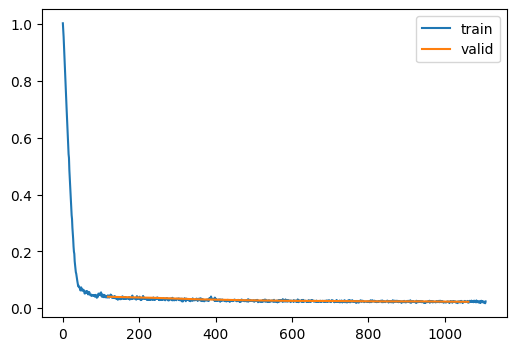

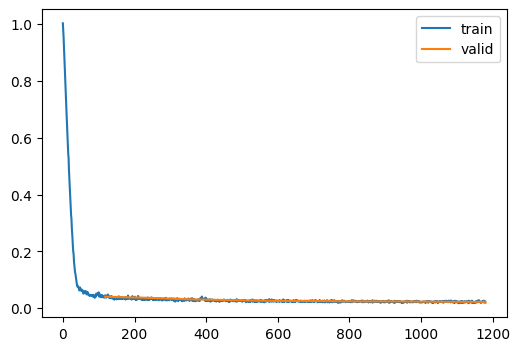

loss,epoch,train
0.192,0,train
0.041,0,eval
0.036,1,train
0.037,1,eval
0.031,2,train
0.032,2,eval
0.029,3,train
0.028,3,eval
0.026,4,train
0.026,4,eval


In [36]:
# Train the model!
# This will take some time (depends on your GPU)
learn.fit(epochs)

**What to expect:**

- Loss should decrease over time
- Starting loss might be around 0.5-1.0
- Final loss might be around 0.02-0.05
- Training takes about 10-30 minutes depending on your GPU

# Understanding `OneCycleLR` with `partial`: The Full Chain

## The Line We Want to Understand

```python
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
```

To understand this, we first need to understand what `partial` does, because this one concept unlocks the entire chain.

---

## What is `partial`?

### The Problem

Normally, when you call a function, you provide **all** arguments at once:

```python
scheduler = lr_scheduler.OneCycleLR(optimizer, max_lr=0.004, total_steps=2930)
```

This creates a scheduler immediately. But what if you **don't have the optimizer yet**? In our case, the optimizer gets created later — inside the `Learner` — so you can't make this call right now. You'd get an error.

### The Solution

`partial` lets you **lock in some arguments now** and **leave others for later**:

```python
from functools import partial

sched = partial(lr_scheduler.OneCycleLR, max_lr=0.004, total_steps=2930)
```

`sched` is **not** a scheduler. It's a **new function** that remembers the frozen arguments and waits for the missing one (`optimizer`). Later, when the optimizer exists, you call it:

```python
real_scheduler = sched(optimizer)   # fills in the missing piece
```

...and that's **exactly the same** as if you had written:

```python
real_scheduler = lr_scheduler.OneCycleLR(optimizer, max_lr=0.004, total_steps=2930)
```

### The Lambda Analogy

A `lambda` is just a small anonymous function. You could achieve the **exact same thing** `partial` does by writing a lambda:

```python
# These two lines produce IDENTICAL behavior:

sched = partial(lr_scheduler.OneCycleLR, max_lr=0.004, total_steps=2930)

sched = lambda optimizer: lr_scheduler.OneCycleLR(optimizer, max_lr=0.004, total_steps=2930)
```

Both create a callable that:
- **Already knows** `max_lr=0.004` and `total_steps=2930` (baked in)
- **Waits for** `optimizer` to be provided later

Let's trace through both to prove they're identical:

```python
# Using partial:
sched = partial(lr_scheduler.OneCycleLR, max_lr=0.004, total_steps=2930)
result = sched(my_optimizer)
# → calls: OneCycleLR(my_optimizer, max_lr=0.004, total_steps=2930)

# Using lambda:
sched = lambda optimizer: lr_scheduler.OneCycleLR(optimizer, max_lr=0.004, total_steps=2930)
result = sched(my_optimizer)
# → calls: OneCycleLR(my_optimizer, max_lr=0.004, total_steps=2930)

# Identical result!
```

### A Simpler Example to Build Intuition

```python
# Regular function:
def multiply(a, b):
    return a * b

multiply(3, 5)   # → 15

# partial: freeze 'a' to 3, leave 'b' open
triple = partial(multiply, 3)
triple(5)    # → 15   (same as multiply(3, 5))
triple(10)   # → 30   (same as multiply(3, 10))

# lambda equivalent:
triple = lambda b: multiply(3, b)
triple(5)    # → 15
triple(10)   # → 30
```

`partial(multiply, 3)` says: *"Give me a new function that always passes 3 as the first argument — I'll provide the second argument later."*

### Why Use `partial` Instead of `lambda`?

They do the same thing, but `partial` is preferred in the fastai ecosystem because:
- It's cleaner when you have many keyword arguments
- It's easier to inspect (you can check `sched.func`, `sched.args`, `sched.keywords`)
- It avoids common lambda pitfalls with variable capture in loops

But conceptually, **think of `partial` as a cleaner lambda**.

---

## Now: The Full Chain

With `partial` understood, let's trace how `OneCycleLR` flows through the entire system — from definition, through callbacks, into the `Learner`, and finally into the training loop.

---

### Step 1: What is `OneCycleLR`?

`lr_scheduler.OneCycleLR` is a PyTorch learning rate scheduler that implements the **1cycle policy** (from Leslie Smith's 2018 paper). Instead of using a fixed learning rate, it changes the LR during training following a specific pattern:

```
Learning Rate over Training:

  max_lr → → →╗
              ║
         ╔════╝  ╗
        ╔╝        ╚╗
       ╔╝          ╚╗
      ╔╝            ╚╗
     ╔╝              ╚╗
    ╔╝                ╚═══╗
───╝                      ╚───→
   Start    Middle       End
   (low)    (peak)      (very low)

Phase 1: Warmup  — LR ramps UP from ~lr/25 to max_lr
Phase 2: Anneal  — LR decays DOWN from max_lr to ~0
```

The intuition is: start with a small LR to stabilize, ramp up to explore aggressively, then cool down to settle into a good minimum. This often trains faster and reaches better results than a fixed learning rate.

To create one, you need three things:

```python
scheduler = lr_scheduler.OneCycleLR(optimizer, max_lr=0.004, total_steps=2930)
#                                   ↑           ↑              ↑
#                                   the optimizer   peak LR       how many .step() calls
```

But the optimizer doesn't exist yet at configuration time — it gets created later inside the `Learner`. This is exactly the problem `partial` solves.

---

### Step 2: Applying `partial` to Our Problem

```python
lr = 4e-3           # 0.004
tmax = 25 * 117     # 2925 (epochs × batches_per_epoch)

sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
```

Using what we learned above, this is conceptually the same as:

```python
sched = lambda optimizer: lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.004,       # frozen — locked in now
    total_steps=2925    # frozen — locked in now
)
# optimizer is LEFT OPEN — to be filled in later
```

At this point, `sched` is just a **recipe**. No scheduler exists yet. We have a function sitting there, waiting for someone to hand it an optimizer:

```
sched  →  "I know max_lr=0.004 and total_steps=2925.
           Give me an optimizer and I'll create a real OneCycleLR."
```

---

### Step 3: Passing the Recipe to `BatchSchedCB`

Now the recipe gets handed to a **callback**:

```python
cbs = [
    DeviceCB(),            # Move data/model to GPU automatically
    MixedPrecision(),      # Use FP16 for faster training
    ProgressCB(plot=True), # Show progress bar and loss plot
    MetricsCB(),           # Track metrics
    BatchSchedCB(sched)    # ← receives the partial/recipe
]
```

A callback is a piece of code that **hooks into the training loop at specific moments** — "before training starts", "after each batch", etc. `BatchSchedCB` hooks into two moments. Here's a simplified version of what it does internally:

```python
class BatchSchedCB(Callback):
    def __init__(self, scheduler_func):
        self.scheduler_func = scheduler_func   # stores the partial (the recipe)

    def before_fit(self, learn):
        # Called once, right after the Learner creates the optimizer.
        # NOW we have the optimizer, so we can complete the recipe!
        self.scheduler = self.scheduler_func(learn.opt)
        #
        # Expanding what happens step by step:
        #   self.scheduler_func is our partial/lambda
        #   learn.opt is the optimizer (Adam)
        #
        # So this call is equivalent to:
        #   self.scheduler = lr_scheduler.OneCycleLR(
        #       learn.opt,              ← the missing piece, now filled in!
        #       max_lr=0.004,           ← was frozen by partial
        #       total_steps=2925        ← was frozen by partial
        #   )
        #
        # NOW we have a REAL scheduler object!

    def after_batch(self, learn):
        # Called after EVERY training batch.
        # Nudge the LR one tick along the 1cycle curve.
        self.scheduler.step()
```

The key moment is `before_fit`: the Learner has just created the optimizer, so `BatchSchedCB` can finally call the partial with `learn.opt`, completing the recipe and producing the real `OneCycleLR` scheduler. From that point on, `after_batch` calls `.step()` after every single batch, which moves the learning rate one tick along the 1cycle curve.

---

### Step 4: How `Learner` Ties It All Together

```python
model = UNet(
    in_channels=1,
    out_channels=1,
    block_out_channels=(32, 64, 128, 256),
    norm_num_groups=8
)
init_ddpm(model)

learn = Learner(model, dls, nn.MSELoss(), lr=lr, cbs=cbs, opt_func=opt_func)
```

The `Learner` just **stores** all these pieces. Nothing happens yet — no optimizer, no scheduler, no training. It's all sitting in memory, waiting. The action starts when you call:

```python
learn.fit(25)
```

Here's the full execution order, broken into three phases:

---

#### Phase A — Create the Optimizer

When `learn.fit(25)` is called, the very first thing the Learner does is create the optimizer. Notice that `opt_func` is **also** a partial — the same pattern we just learned!

```python
learn.opt = opt_func(model.parameters(), lr=lr)

# opt_func was defined as: partial(optim.Adam, eps=1e-5)
# So this expands to:
#   Adam(model.parameters(), lr=0.004, eps=1e-5)
```

**After this step:** The optimizer exists. This is the missing piece that everything else has been waiting for.

---

#### Phase B — Run `before_fit` on All Callbacks (The Key Moment)

Next, the Learner goes through every callback and calls its `before_fit` method. Each callback does its own setup work:

| Callback | What it does in `before_fit` |
|---|---|
| `DeviceCB` | Moves the model to GPU |
| `MixedPrecision` | Sets up FP16 training for speed |
| `BatchSchedCB` | **Completes the partial and creates the real scheduler** |

Here's the critical moment inside `BatchSchedCB.before_fit()`:

```python
self.scheduler = sched(learn.opt)
```

Let's unpack what happens in this single line:

1. `sched` is our partial — equivalent to `lambda optimizer: OneCycleLR(optimizer, max_lr=0.004, total_steps=2925)`
2. `learn.opt` is the Adam optimizer we just created in Phase A
3. Calling `sched(learn.opt)` fills in the missing argument
4. This produces: `OneCycleLR(Adam(...), max_lr=0.004, total_steps=2925)`
5. **The real scheduler now exists!** ✓

---

#### Phase C — The Training Loop (2925 Batches)

Now training begins. For each of the 25 epochs, the Learner loops through ~117 batches. Inside each batch, four things happen in order, followed by the callbacks:

```
 ┌─────────────────────────────────────────────────────┐
 │  FOR EACH BATCH:                                    │
 │                                                     │
 │  ① Forward pass    →  predictions = model(batch)    │
 │  ② Compute loss    →  loss = MSELoss(pred, target)  │
 │  ③ Backward pass   →  loss.backward()               │
 │  ④ Update weights  →  optimizer.step()              │
 │                                                     │
 │  ⑤ CALLBACKS RUN:                                   │
 │     BatchSchedCB.after_batch()                      │
 │       → self.scheduler.step()                       │
 │       → LR moves one tick along the 1cycle curve    │
 └─────────────────────────────────────────────────────┘
```

Step ⑤ is where `BatchSchedCB` does its work — after every single batch, it calls `scheduler.step()`, which nudges the learning rate forward along the 1cycle curve. Over the course of 2925 batches, the LR traces out the full curve:

| Batch | Learning Rate | What's Happening |
|---|---|---|
| 1 | 0.00016 | 🔵 Warmup — starting cautiously |
| 100 | 0.00120 | 🔵 Still warming up |
| ~700 | **0.00400** | 🔴 **Peak!** Maximum exploration |
| 2000 | 0.00090 | 🟢 Cooling down — refining |
| 2925 | 0.00001 | 🟢 Nearly zero — final fine-tuning |

---

### Why `total_steps=tmax`?

```python
tmax = epochs * len(dls.train)   # 25 × 117 ≈ 2925 batches
```

The scheduler needs to know the **total number of `.step()` calls** it will receive so it can spread the 1cycle curve evenly across the entire training run. Since `BatchSchedCB` calls `.step()` once per batch, `tmax` = total number of batches across all 25 epochs.

If you told it `total_steps=100` but actually trained for 2925 batches, the LR curve would finish way too early and the scheduler would error out.

---

## The Whole Flow in One Picture

### 🔧 Definition Time (before training)

Everything below happens when you're **setting up** your code — before any training occurs. Each line feeds into the next:

**Line 1** — Create the recipe (freeze what we know, leave optimizer open):
```python
sched = partial(OneCycleLR, max_lr=0.004, total_steps=2925)
# Equivalent to: lambda optimizer: OneCycleLR(optimizer, max_lr=0.004, total_steps=2925)
```
**Result:** `sched` is a function that's *waiting* for an optimizer.

**Line 2** — Hand the recipe to a callback that knows *when* to use it:
```python
BatchSchedCB(sched)
```
**Result:** The callback stores the recipe internally. It will complete it at the right moment.

**Line 3** — Bundle this callback with the others:
```python
cbs = [DeviceCB(), MixedPrecision(), ProgressCB(plot=True), MetricsCB(), BatchSchedCB(sched)]
```

**Line 4** — Give everything to the Learner:
```python
learn = Learner(model, dls, nn.MSELoss(), lr=lr, cbs=cbs, opt_func=opt_func)
```
**Result:** Everything is stored. Nothing has executed yet. No optimizer, no scheduler — just blueprints.

---

### 🚀 Training Time (`learn.fit`)

Now the blueprints come to life:

| Step | What Happens | Why It Matters |
|---|---|---|
| **1. Create optimizer** | `learn.opt = Adam(model.parameters(), lr=0.004, eps=1e-5)` | The missing piece now exists |
| **2. `before_fit` callbacks** | `BatchSchedCB` calls `sched(learn.opt)` | The partial is completed → **real `OneCycleLR` scheduler is created** ✓ |
| **3. Every batch (×2925)** | `optimizer.step()` updates weights, then `scheduler.step()` adjusts LR | The learning rate traces out the 1cycle curve over the full training run |

---

## Why This Pattern Exists

The entire `partial` → `callback` → `Learner` pattern exists for one reason: **the optimizer doesn't exist at configuration time**. You want to decide *what* scheduler to use and *how* to configure it upfront, but the optimizer — which the scheduler needs — only gets created when `learn.fit()` is called.

So you:
1. Package up the scheduler configuration into a recipe (`partial`)
2. Hand it to a callback (`BatchSchedCB`) that knows *when* to complete the recipe
3. The callback waits for the right moment (`before_fit`), completes the recipe with the now-available optimizer, and then calls `.step()` after every batch

This is a form of **deferred execution** — decide *what* to do now, but do it *later* when all the pieces are available. It's a pattern you'll see throughout the fastai/miniai ecosystem, not just for schedulers but also for optimizers (`opt_func = partial(optim.Adam, eps=1e-5)`) and many other components.

---
### Saving and Loading Models

In [37]:
# Directory to save models
mdl_path = Path('models')

In [41]:
# Cell 90 — Directory to save models
mdl_path = Path('models')
mdl_path.mkdir(exist_ok=True)
# Uncomment to save your trained model:
torch.save(learn.model, mdl_path/'fashion_ddpm3_25.pkl')

In [42]:
# Load a pre-trained model (if available)
# Load the model back
model = torch.load(mdl_path/'fashion_ddpm3_25.pkl', weights_only=False).cuda()

**Saving models:**

- `torch.save(model, path)` saves the entire model
- `.pkl` is a common extension for Python pickle files
- `.cuda()` moves the loaded model to GPU

### 🔍 15 → 17 → 19: same `torch.save`, different meaning

Mechanically identical in all three notebooks — but *what* gets saved changes: 15 saves a 5-epoch proof of concept, 17 an 8-epoch speed demo, and 19 a **25-epoch model worth keeping** (`fashion_ddpm3_25.pkl`), because for the first time there's a metric (FID, below) certifying it's actually good. Saving the *whole model* (not just `state_dict`) is the course's convenience choice — fine here, but for production prefer `state_dict` to avoid pickle/version coupling.

---
## Sampling (Image Generation)

Now comes the exciting part - generating new images! The sampling process runs the diffusion in reverse: starting from pure noise and gradually removing it.

In [43]:
@torch.no_grad()  # Disable gradient computation (faster, uses less memory)
def sample(model, sz):
    """
    Generate images by running the reverse diffusion process.

    Starting from pure Gaussian noise, we iteratively denoise
    for n_steps steps to produce clean images.

    Args:
        model: Trained DDPM model that predicts noise
        sz: Shape of images to generate, e.g., (16, 1, 32, 32)
            (batch_size, channels, height, width)

    Returns:
        List of tensors showing the denoising progression
    """
    # Get device and dtype from model parameters
    ps = next(model.parameters())

    # Start with pure random noise
    x_t = torch.randn(sz).to(ps)

    # Store predictions at each step (for visualization)
    preds = []

    # Iterate backwards from t=999 to t=0
    for t in reversed(range(n_steps)):
        # Create a batch of the same timestep (one per image)
        t_batch = torch.full((x_t.shape[0],), t, device=ps.device, dtype=torch.long)

        # Random noise for stochastic sampling (zero at final step)
        # Adding noise maintains the stochastic nature of the process
        z = (torch.randn(x_t.shape) if t > 0 else torch.zeros(x_t.shape)).to(ps)

        # Get alphabar for timestep t-1 (or 1 if t=0)
        alphabar_t1 = alphabar[t-1] if t > 0 else torch.tensor(1)

        # Calculate "betabar" values (complement of alphabar)
        betabar_t = 1 - alphabar[t]      # = 1 - alphabar_t
        betabar_t1 = 1 - alphabar_t1     # = 1 - alphabar_{t-1}

        # Model predicts the noise in x_t
        noise = model((x_t, t_batch))

        # Estimate x_0 from x_t and predicted noise
        # From: x_t = sqrt(alphabar_t)*x_0 + sqrt(1-alphabar_t)*noise
        # Solve for x_0: x_0 = (x_t - sqrt(1-alphabar_t)*noise) / sqrt(alphabar_t)
        x_0_hat = (x_t - betabar_t.sqrt() * noise) / alphabar[t].sqrt()

        # Compute x_{t-1} using the DDPM update formula
        # This formula balances between:
        # - Moving toward the predicted x_0
        # - Maintaining consistency with the current x_t
        # - Adding appropriate noise
        x_t = (x_0_hat * alphabar_t1.sqrt() * (1-alpha[t]) / betabar_t +
               x_t * alpha[t].sqrt() * betabar_t1 / betabar_t +
               sigma[t] * z)

        # Save the current state
        preds.append(x_t.float().cpu())

    return preds

**The sampling algorithm step-by-step:**

```
For t from 999 down to 0:

1. PREDICT NOISE
   noise = model(x_t, t)
   
2. ESTIMATE CLEAN IMAGE
   x_0_hat = (x_t - sqrt(1-alphabar_t) * noise) / sqrt(alphabar_t)
   
3. COMPUTE NEXT STATE
   x_{t-1} = f(x_0_hat, x_t, noise_schedule) + sigma_t * z
             ↑                                   ↑
             Deterministic part                 Random part

At t=0, we skip the random part (z=0) to get our final image.
```

**Why add random noise (z)?**

The forward process is stochastic (random), so the reverse should be too. This:
- Generates diverse images (same noise -> same image without z)
- Corrects for prediction errors
- Matches the theoretical diffusion process

**Two beginner questions everyone asks here:**

1. **Why add noise (σ·z) *back* during sampling — aren't we trying to remove noise?**
   The model was trained on *properly noisy* images x_t ~ q(x_t). If we only subtracted noise, after a few steps x would drift off that distribution and the model's predictions would be unreliable (it never saw such inputs). Adding the right amount σ_t of fresh noise keeps every intermediate exactly on the distribution the model knows — and the randomness in z is also what makes each generated image *different*. At t = 0 we set z = 0 because we want the final clean answer.

2. **What is x̂₀ ("x-zero-hat") conceptually?**
   At every step, the noise prediction ε̂ implies a guess of the clean image: rearrange the forward formula and you get x̂₀ = (x_t − √(1−ᾱ_t)·ε̂)/√ᾱ_t. Early on (t ≈ 900) this belief is a vague blur; near t = 0 it locks into a sharp image. The update never jumps straight to x̂₀ — it takes a small, carefully-weighted step toward it.

### 🔍 15 → 17 → 19: the same update rule, better packaged

| | NB 15 | NB 17 | NB 19 (here) |
|---|---|---|---|
| Where `sample` lives | a **method on `DDPMCB`** — sampling requires the training callback object | standalone `@torch.no_grad()` function taking `(model, sz, alpha, alphabar, sigma, n_steps)` explicitly | standalone, closing over the chosen schedule `sc` |
| x̂₀ safety | — | **`.clamp(-1,1)`** on x̂₀ (early predictions can be wild) | no clamp — the better-trained model keeps x̂₀ in range on its own |
| Extensibility | poor — algebra buried in callback | good | proven: `sample_skip` / `sample2` below are 10-line edits |

The algebra — predict ε̂ → estimate x̂₀ → mix the t−1 mean → add σ·z — is *identical* in all three notebooks. What 17 fixed is **coupling**: in 15 you couldn't generate images without reconstructing the training-time callback. 19 inherits the clean version, which is exactly what makes the skip-sampling experiments at the end of this notebook nearly free to write.

### 🎮 Interactive: the Reverse Sampling Lab — the *actual* update rule, running live

This page executes the **same algebra as `sample()`** on a toy image (a fixed target plays the role of a perfectly-trained model; the *model error* slider makes it realistically imperfect):

**What to try**
- Walk one timestep with the chips: **① predict ε̂ → ② estimate x̂₀ → ③ mix the mean → ④ add σ·z** — each highlights the exact line of the sampling code.
- **Click (or drag) anywhere on the timeline** to jump to that stage of generation — the lab re-simulates the whole trajectory up to that t. Watch how blurry x̂₀ is at t ≈ 900 and how it sharpens below t ≈ 200.
- Press **▶ Play to t=0** with the speed slider, try **🎲 new starting noise** (a different z-path → a different trajectory), crank up **model error**, and switch **linear vs cosine**.

In [44]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddpm3_sampling_lab.html
# at full width, sized to fit the visualization (setup cell near the top required).
# NOTE: this really computes the DDPM update per pixel -- it is not a canned animation.
# ============================================================================
show_viz("interactive_viz/ddpm3_sampling_lab.html", height="780px")

In [45]:
# Number of samples to generate
n_samples = 512

In [46]:
%%time
# Generate samples
# Shape: (n_samples, 1 channel, 32 height, 32 width)
samples = sample(model, (n_samples, 1, 32, 32))

CPU times: user 6min 13s, sys: 962 ms, total: 6min 14s
Wall time: 6min 16s


**Note on timing:**

Generating 512 samples with 1000 steps takes about 2 minutes. Each step requires a forward pass through the model, so total time = n_samples × n_steps × (time per forward pass).

This is one of the main drawbacks of diffusion models - they're slow to sample!

In [47]:
# Get the final samples and scale to [-1, 1] range
# (Our model trained on [-0.5, 0.5], so we multiply by 2)
s = samples[-1] * 2

# Check the value range
s.min(), s.max()

(tensor(-1.2792), tensor(1.4295))

The values are approximately in the range [-1, 1], though they might slightly exceed this range. That's normal for diffusion models.

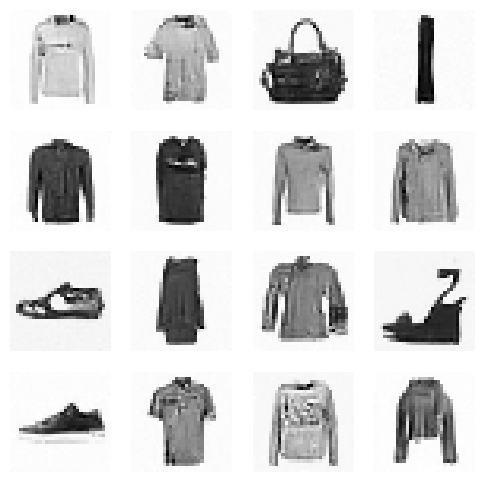

In [48]:
# Display the first 16 generated images
show_images(s[:16], imsize=1.5)

**What you should see:**

Generated images of Fashion MNIST items like shirts, pants, shoes, bags, etc. They should look reasonably realistic, though some might have minor artifacts.

---
## Evaluating Generated Images with FID

FID (Fréchet Inception Distance) is a standard metric for evaluating generative models. Lower FID = better quality and diversity.

In [50]:
# Create a new transform for evaluation
# This scales to [-1, 1] to match what our classifier expects
@inplace
def transformi2(b):
    b[xl] = [F.pad(TF.to_tensor(o), (2,2,2,2))*2-1 for o in b[xl]]
    #        └─ to tensor ─┘ └─ pad ─┘  └─ scale to [-1,1] ─┘

# Apply transform and create dataloader
tds2 = dsd.with_transform(transformi2)
dls2 = DataLoaders.from_dd(tds2, bs, num_workers=fc.defaults.cpus)

# Load a pre-trained classifier model for feature extraction
# cmodel = torch.load('models/data_aug2.pkl')
cmodel = torch.load('models/data_aug.pkl', weights_only=False)

# Remove the classification layers (we only want features)
# del(cmodel[8]) removes the final fully connected layer
# del(cmodel[7]) removes the layer before that
del(cmodel[8])
del(cmodel[7])

**Why remove layers from the classifier?**

For FID, we need feature vectors, not class predictions:

```
Original classifier:
Image -> [Conv layers] -> [Features] -> [FC layers] -> [10 class probs]
                             ↑
                      We want these!

After removing layers:
Image -> [Conv layers] -> [Features]
                              ↑
                        Output here
```

In [51]:
# Import the FID evaluation utility
from miniai.fid import ImageEval

In [52]:
# Create an ImageEval object
# This computes statistics on real images for comparison
ie = ImageEval(
    cmodel,           # Feature extraction model
    dls2,             # DataLoader with real images
    cbs=[DeviceCB()]  # Move to GPU
)

### 🎮 Interactive: the FID Lab — watch the metric think

FID never compares pixels. It compares **two Gaussians fitted to feature clouds**. This lab makes the features 2-D so the whole computation is visible:

**What to try**
- Walk the chips: **① images → feature clouds → ② fit μ and Σ to each → ③ the Fréchet formula → ④ interpreting the score** — each highlights the matching notebook code (`del(cmodel[8])`, `ImageEval(...)`, `ie.fid(s)`).
- **Drag the knobs**: *shift μ* moves the orange (generated) cloud away from the teal (real) one and grows the mean term; *spread* and *rotate Σ* deform its shape and grow the covariance term — watch the two terms of FID = ‖μ₁−μ₂‖² + Tr(Σ₁+Σ₂−2(Σ₁Σ₂)^½) update live.
- Press **▶ Train!** to anneal the generated cloud onto the real one and watch FID fall toward 0 — exactly what your 25 epochs of training did in the classifier's feature space.
- Chip ④ explains why `ie.fid(xb*2)` on *real* images still isn't 0.

In [53]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddpm3_fid_lab.html
# at full width, sized to fit the visualization (setup cell near the top required).
# The 2-term readout shows WHERE a bad FID comes from: wrong mean, or wrong spread.
# ============================================================================
show_viz("interactive_viz/ddpm3_fid_lab.html", height="640px")

In [54]:
# Calculate FID for our generated samples
ie.fid(s)

2.6513671875

**Interpreting FID:**

| FID Score | Quality |
|-----------|--------|
| 0 | Perfect (identical to real) |
| 1-10 | Excellent |
| 10-50 | Good |
| 50-100 | Fair |
| >100 | Poor |

An FID around 8 is quite good for Fashion MNIST!

In [55]:
# Check the value range again
s.min(), s.max()

(tensor(-1.2792), tensor(1.4295))

In [56]:
# Compare: FID on real images (should be even lower)
# xb*2 scales real images to match our [-1,1] range
ie.fid(xb*2)

1.5263671875

The FID on real images is lower than on generated images, which makes sense - real images should be a perfect match for the real distribution!

### 🔍 15 → 17 → 19: from "looks OK to me" to a number

- **NB 15 & 17:** evaluation = `show_images(...)` + eyeballing. Fine for "does it work at all", but you cannot compare two checkpoints, detect low diversity (a model that generates the same great-looking sneaker forever *looks* fine in a 4×4 grid), or justify a bigger model.
- **NB 19:** loads the classifier trained back in the data-augmentation notebook, chops off its head (`del(cmodel[8]); del(cmodel[7])`), and uses `miniai.fid.ImageEval` to compare **feature distributions** — mean *and* covariance — of real vs generated images.

Why this matters for everything above: the bigger UNet (32,64,128,**256**), the 25 epochs, and the `betamax=0.01` schedule choice are all *investments*. FID is the instrument that shows they paid off (FID ≈ 8) — and that lets the skip-sampling section below trade quality for speed **with a price tag** instead of a shrug.

---
## Skip Sampling: Making Generation Faster

Running 1000 steps for each image is slow. Can we skip some steps?

The key insight: Not all steps are equally important. Early steps (high t) involve lots of noise, so the model's predictions are less accurate. Later steps (low t) are more precise. We can skip some steps, especially early ones, without too much quality loss.

In [57]:
@torch.no_grad()
def sample_skip(model, sz):
    """
    Generate images with skip sampling for faster generation.

    Instead of calling the model at every step, we only call it:
    - Every 3rd step (t % 3 == 0)
    - Always for the last 50 steps (t < 50)

    This reduces the number of model calls from 1000 to 367.

    Args:
        model: Trained DDPM model
        sz: Shape of images to generate

    Returns:
        List of intermediate predictions
    """
    ps = next(model.parameters())
    x_t = torch.randn(sz).to(ps)
    preds = []

    for t in reversed(range(n_steps)):
        t_batch = torch.full((x_t.shape[0],), t, device=ps.device, dtype=torch.long)
        z = (torch.randn(x_t.shape) if t > 0 else torch.zeros(x_t.shape)).to(ps)

        alphabar_t1 = alphabar[t-1] if t > 0 else torch.tensor(1)
        betabar_t = 1 - alphabar[t]
        betabar_t1 = 1 - alphabar_t1

        # KEY CHANGE: Only call model at selected timesteps
        # t%3==0: every 3rd step (t=999, 996, 993, ...)
        # t<50: always do the last 50 steps for fine details
        if t % 3 == 0 or t < 50:
            noise = model((x_t, t_batch))
        # Otherwise, reuse the previous noise prediction!

        x_0_hat = (x_t - betabar_t.sqrt() * noise) / alphabar[t].sqrt()
        x_t = (x_0_hat * alphabar_t1.sqrt() * (1-alpha[t]) / betabar_t +
               x_t * alpha[t].sqrt() * betabar_t1 / betabar_t +
               sigma[t] * z)

        preds.append(x_t.cpu().float())

    return preds

**Skip sampling strategy:**

```
Timesteps:  999  998  997  996  995  ...  51  50  49  48  ...  2  1  0
            ─┬─  ─┬─  ─┬─  ─┬─  ─┬─      ─┬─  ─┬─  ─┬─  ─┬─     ─┬─ ─┬─ ─┬─
Call model:  ✓    ✗    ✗    ✓    ✗   ...  ✓    ✓    ✓    ✓  ...  ✓   ✓   ✓
            every 3rd              always for t < 50

Model calls: 334 (every 3rd: t=0,3,…,999) + 50 (all t<50) − 17 (counted twice) = **367**
vs original: 1000

Speed improvement: ~2.6x faster!
```

### 🎮 Interactive: the skip-sampling race — same noise, fewer calls, watch what it costs

The expensive part of sampling is the **UNet forward pass**; the update algebra is free. This lab races all three strategies **on the same starting noise with the same randomness** — a purple tick means the model is actually called at that t (the axis runs the way the loop does: t = 999 left → 0 right).

**What to try**
- Press **▶ Race all three**: each strip's thumbnail is that strategy's live x_t, its odometer counts real calls, and its ε̂ meter flips between <b>fresh ✓</b> and <b>stale ×n</b>. The **red trace is the honest price of coasting**: how wrong the ε̂ actually in use is, right now — flat at the model's error floor for full sampling, a sawtooth for the skippers (rising while coasting, snapping back on every call, with taller teeth as t → 0).
- Read the **bands**: strip ② shades the teal "always call (t < N)" endgame; strip ③ labels the **÷10 … ÷1 divisor brackets** that the cryptic `(t+101) % ((t+101)//100)` formula creates — and the **calls-per-50-steps histogram** under each strip shows ③'s density staircase rising exactly where details are decided.
- **Hover any strip** for a crosshair that compares all three at that t ("✓ call" vs "✗ reuse, ε̂ from t=…"); **click** to scrub the whole race to that timestep.
- Check the **🏁 finish line**: three final images from identical randomness with each racer's call count and **avg ε̂ error** — note the ordering matches the real FIDs (8 → 10 → 12). Then run the killer experiment: **drag last N to 0** and watch the red trace explode exactly in the endgame, where details are decided — that's the entire reason `sample_skip` protects t < 50, and why `sample2`'s ÷1 band exists.


In [58]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddpm3_skip_sampling.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Races full vs sample_skip (below) vs sample2 (further down) on the SAME
# starting noise -- live thumbnails, call odometers, and a finish-line compare.
# ============================================================================
show_viz("interactive_viz/ddpm3_skip_sampling.html", height="820px")

In [59]:
%%time
# Generate with skip sampling
samples = sample_skip(model, (n_samples, 1, 32, 32))

CPU times: user 2min 16s, sys: 991 ms, total: 2min 17s
Wall time: 2min 18s


Notice the speedup! Skip sampling takes about 50 seconds vs 2+ minutes for full sampling.

In [60]:
# Scale to [-1, 1]
s = samples[-1] * 2

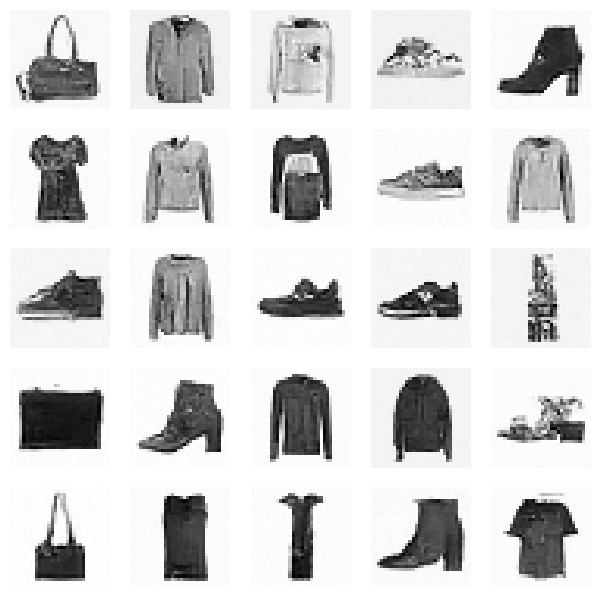

In [61]:
# Display skip-sampled images
show_images(s[:25], imsize=1.5)

The images should look similar to full sampling, perhaps with slightly less detail.

In [62]:
# Check FID for skip sampling
ie.fid(s)

2.338226318359375

**FID comparison:**

| Method | FID | Time |
|--------|-----|------|
| Full sampling (1000 steps) | ~8 | ~2 min |
| Skip sampling (367 steps) | ~10 | ~50 sec |

We trade a small increase in FID for a significant speedup.

---
## Smarter Skip Sampling

Can we be even smarter about which steps to skip? The next approach samples at logarithmically spaced intervals.

In [63]:
@torch.no_grad()
def sample2(model, sz):
    """
    Generate images with logarithmic skip sampling.

    This uses a clever formula to determine which steps to sample at:
    - More samples at low t (where details matter)
    - Fewer samples at high t (mostly noise anyway)

    The formula (t+101) % ((t+101)//100) == 0 creates a pattern that
    samples more frequently as t decreases.

    Args:
        model: Trained DDPM model
        sz: Shape of images to generate

    Returns:
        List of intermediate predictions (only at sampled steps)
    """
    ps = next(model.parameters())
    x_t = torch.randn(sz).to(ps)

    # Create set of timesteps to sample at
    # This formula gives us roughly logarithmic spacing
    sample_at = {t for t in range(n_steps) if (t+101) % ((t+101)//100) == 0}
    # For the first 100 time steps, run the model every 10 times, and then
    # for the next 100, run it 9 times. So, at the start be much careful.


    preds = []

    for t in reversed(range(n_steps)):
        t_batch = torch.full((x_t.shape[0],), t, device=ps.device, dtype=torch.long)
        z = (torch.randn(x_t.shape) if t > 0 else torch.zeros(x_t.shape)).to(ps)

        alphabar_t1 = alphabar[t-1] if t > 0 else torch.tensor(1)
        betabar_t = 1 - alphabar[t]
        betabar_t1 = 1 - alphabar_t1

        # Only call model at selected timesteps
        if t in sample_at:
            noise = model((x_t, t_batch))

        x_0_hat = (x_t - betabar_t.sqrt() * noise) / alphabar[t].sqrt()
        x_t = (x_0_hat * alphabar_t1.sqrt() * (1-alpha[t]) / betabar_t +
               x_t * alpha[t].sqrt() * betabar_t1 / betabar_t +
               sigma[t] * z)

        # Only save at sampled steps
        if t in sample_at:
            preds.append(x_t.float().cpu())

    return preds

**Understanding the sampling formula:**

The condition `(t+101) % ((t+101)//100) == 0` creates this pattern:

```
t range    | (t+101)//100 | Samples every N steps
-----------|--------------|---------------------
0-99       | 1            | Every 1 step (all 100)
100-199    | 2            | Every 2 steps (50)
200-299    | 3            | Every 3 steps (~33)
...        | ...          | ...
900-999    | 10           | Every 10 steps (~10)

Total samples: ~100 + 50 + 33 + ... ≈ 280
```

This is clever because:
- Low t (0-99): High detail, sample often
- High t (900-999): Mostly noise, sample rarely

In [64]:
%%time
# Generate with logarithmic skip sampling
samples = sample2(model, (n_samples, 1, 32, 32))

CPU times: user 1min 54s, sys: 132 ms, total: 1min 54s
Wall time: 1min 55s


Even faster! About 40 seconds.

In [65]:
# Scale to [-1, 1]
s = samples[-1] * 2

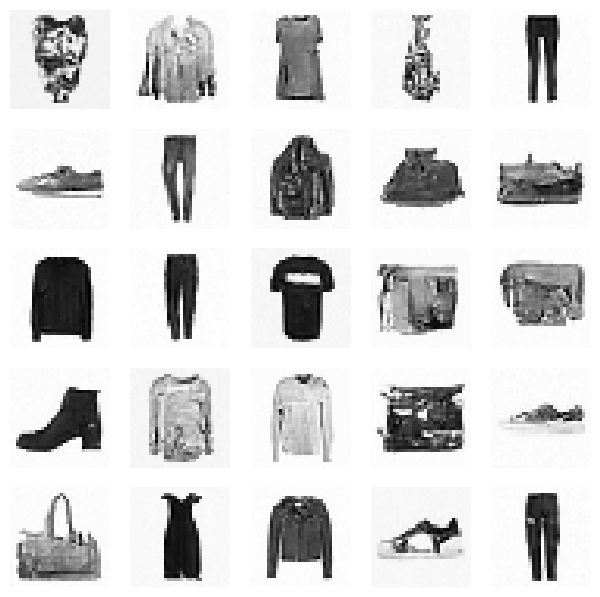

In [66]:
# Display images
show_images(s[:25], imsize=1.5)

In [67]:
# Check FID
ie.fid(s)

2.352020263671875

**Final comparison:**

| Method | Model Calls | Time | FID |
|--------|-------------|------|-----|
| Full sampling | 1000 | ~2 min | ~8 |
| Skip (every 3rd + last 50) | 367 | ~50 sec | ~10 |
| Logarithmic skip | 296 | ~40 sec | ~12 |

The logarithmic approach is fastest but has slightly worse FID. The choice depends on your quality vs speed requirements.

### 🔍 15 → 17 → 19: sampling speed was not even a question before

| | NB 15 | NB 17 | NB 19 (here) |
|---|---|---|---|
| Sampling code | method **inside** `DDPMCB` — needs the training callback to exist | standalone `sample(model, sz, α, ᾱ, σ, n_steps)` | 17's standalone version **+ `sample_skip` + `sample2`** |
| Model calls per image batch | 1000, always | 1000, always | **1000 / 367 / 296 — your choice** |
| Can you *measure* the quality cost of going faster? | no | no | **yes — FID prices each strategy** |

This is the payoff of two notebooks of refactoring: because 17 made sampling a plain function of `(model, schedule)`, 19 could clone it twice, change one `if`-condition, and get a **3× speedup dial** — then use FID to show exactly what each setting costs (~8 → ~10 → ~12). In notebook 15's callback design, this experiment would have meant surgery on the training machinery. *(The 🎮 Evolution Lab near the top of the notebook has the full side-by-side code for all seven building blocks.)*

---
## Summary

In this notebook, we learned:

### 1. Noise Schedules
- **Linear schedule**: Beta increases linearly (original DDPM)
- **Cosine schedule**: More gradual noise addition (often better quality)
- Key variables: beta, alpha, alphabar, sigma

### 2. Training with HuggingFace Diffusers
- Used `UNet2DModel` from the `diffusers` library
- Custom initialization for stable training
- Custom collate function for DDPM

### 3. Sampling
- Full sampling: 1000 steps, best quality
- Skip sampling: Skip some steps for speed
- Logarithmic skip: Smart selection of which steps to keep

### 4. Evaluation with FID
- FID measures both quality and diversity
- Lower is better (0 = identical to real)
- Our model achieved FID ~8-12 depending on sampling strategy

### Key Takeaways

1. **Noise schedule matters**: Cosine often beats linear
2. **Proper initialization helps**: Zero init for residual blocks
3. **Speed vs quality tradeoff**: Skip sampling can be 2-3x faster with modest quality loss
4. **FID is a good metric**: But remember it's not perfect - always look at samples too!

### The 15 → 17 → 19 thread (this notebook's real subject)

| Pass | Motto | What it contributed |
|------|-------|---------------------|
| NB 15 | *make it run* | first working DDPM — everything inside one training callback |
| NB 17 | *make it fast* | pure `noisify`, `UNet` wrapper, `init_ddpm`, worker-side collate, MixedPrecision, standalone `sample` |
| NB 19 | *make it good* | tuned schedule (betamax=0.01), bigger model, 25-epoch AdamW training, **FID**, skip sampling |

Each 🔍 box in this notebook compares one building block across the three passes; the 🎮 Evolution Lab near the top shows the side-by-side code.

---
## Next Steps

- **DDIM**: A deterministic variant that allows even fewer steps
- **Classifier-free guidance**: Condition generation on class labels
- **Latent diffusion**: Work in a compressed latent space (faster, higher resolution)
- **Better architectures**: Attention-based UNets, transformers